**<font size="6">Statistical Models for Healthcare Data</font>**

**<font size="5">MSc in Health Informatics - UniSR - A.Y. 2024-2025</font>**

Prof. Lara Cavinato - Dott. Vittorio Torri

---

<font size="4">Lab VI - Survival models</font>

# **Libraries**

In [92]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
import numpy as np

In [95]:
np.random.seed(1234)

In [96]:
import scipy.stats as stats
from scipy.stats import kurtosis, skew, shapiro, chi2_contingency, levene, kruskal, ttest_ind, ttest_ind, pearsonr

In [97]:
from tqdm.notebook import tqdm

In [98]:
!pip install lifelines

In [99]:
from lifelines import KaplanMeierFitter, NelsonAalenFitter, CoxPHFitter
from lifelines.utils import median_survival_times, k_fold_cross_validation
from lifelines.statistics import logrank_test, multivariate_logrank_test

# **Load Dataset**

In [100]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [101]:
PATH = '/content/drive/MyDrive/statistica/'
df = pd.read_csv(PATH + 'dataset_challenge_2.csv')

In [102]:
df

,Unnamed: 0,age,base_IOP,corneal_thickness,vcdr,FUP_IOP,SD_IOP,MAX_IOP,Range_IOP,CV_IOP,sex,familiarity,diabetes,hypertension,cvd,migraine,time,status,ethnicity
0,319,58.67,26.14,563.56,0.17,25.38,1.02,26.50,11.49,0.04,0,0,0,0,0,0,459.36,0,White
1,704,45.72,24.64,586.97,0.33,25.78,1.78,26.53,13.30,0.07,0,0,0,1,0,0,274.00,1,White
2,391,46.47,25.73,557.98,0.50,22.82,1.51,33.70,3.35,0.07,1,0,0,0,0,0,308.71,0,White
3,21,58.12,23.95,530.01,0.42,23.32,2.16,25.52,8.10,0.09,0,0,0,0,0,0,757.49,0,White
4,556,69.27,21.16,596.21,0.61,22.46,2.35,27.33,13.27,0.10,1,0,1,0,0,0,3650.00,0,Black
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
814,361,53.19,19.62,618.72,0.42,20.75,2.06,30.76,4.90,0.10,1,1,0,1,0,0,3650.00,0,Black
815,387,60.71,22.27,580.87,0.24,21.10,2.74,30.58,6.57,0.13,1,0,0,0,0,0,204.00,1,Asian
816,436,45.57,26.57,560.42,0.24,25.53,1.83,26.57,9.35,0.07,0,1,0,0,0,1,400.00,1,White
817,613,56.39,26.87,586.18,0.43,24.84,1.18,29.91,5.81,0.05,0,0,0,1,0,0,461.00,1,White


In [103]:
df = df.drop(columns=['Unnamed: 0'])

In [104]:
print(df.groupby('ethnicity').size())
# Combine Asian, Hispanic, Native American categories into "Other"
df['ethnicity'] = df['ethnicity'].replace({'Asian': 'Other', 'Hispanic': 'Other', 'Native American': 'Other'})
print(df.groupby('ethnicity').size())

ethnicity
Asian                7
Black              180
Hispanic            35
Native American      2
Other               11
White              584
dtype: int64
ethnicity
Black    180
Other     55
White    584
dtype: int64


#**Descriptive Statistics**

In [105]:
df.shape

(819, 18)

In [106]:
df.columns

Index(['age', 'base_IOP', 'corneal_thickness', 'vcdr', 'FUP_IOP', 'SD_IOP',
       'MAX_IOP', 'Range_IOP', 'CV_IOP', 'sex', 'familiarity', 'diabetes',
       'hypertension', 'cvd', 'migraine', 'time', 'status', 'ethnicity'],
      dtype='object')

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 819 entries, 0 to 818
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                819 non-null    float64
 1   base_IOP           819 non-null    float64
 2   corneal_thickness  819 non-null    float64
 3   vcdr               819 non-null    float64
 4   FUP_IOP            819 non-null    float64
 5   SD_IOP             819 non-null    float64
 6   MAX_IOP            819 non-null    float64
 7   Range_IOP          819 non-null    float64
 8   CV_IOP             819 non-null    float64
 9   sex                819 non-null    int64  
 10  familiarity        819 non-null    int64  
 11  diabetes           819 non-null    int64  
 12  hypertension       819 non-null    int64  
 13  cvd                819 non-null    int64  
 14  migraine           819 non-null    int64  
 15  time               819 non-null    float64
 16  status             819 non

In [108]:
num_vars = ['age', 'base_IOP', 'corneal_thickness', 'vcdr', 'FUP_IOP', 'SD_IOP', 'MAX_IOP', 'Range_IOP', 'CV_IOP', 'time']
cat_vars = ['sex', 'familiarity', 'diabetes', 'hypertension', 'cvd', 'migraine', 'status', 'ethnicity']

## Categorical variable

Absolute frequency

In [109]:
for column_name in cat_vars:
    print(df[column_name].value_counts())

sex
0    468
1    351
Name: count, dtype: int64
familiarity
0    518
1    301
Name: count, dtype: int64
diabetes
0    720
1     99
Name: count, dtype: int64
hypertension
0    495
1    324
Name: count, dtype: int64
cvd
0    767
1     52
Name: count, dtype: int64
migraine
0    723
1     96
Name: count, dtype: int64
status
0    540
1    279
Name: count, dtype: int64
ethnicity
White    584
Black    180
Other     55
Name: count, dtype: int64


Relative frequencies

In [110]:
for column_name in cat_vars:
    print(df[column_name].value_counts(normalize=True))

sex
0   0.57
1   0.43
Name: proportion, dtype: float64
familiarity
0   0.63
1   0.37
Name: proportion, dtype: float64
diabetes
0   0.88
1   0.12
Name: proportion, dtype: float64
hypertension
0   0.60
1   0.40
Name: proportion, dtype: float64
cvd
0   0.94
1   0.06
Name: proportion, dtype: float64
migraine
0   0.88
1   0.12
Name: proportion, dtype: float64
status
0   0.66
1   0.34
Name: proportion, dtype: float64
ethnicity
White   0.71
Black   0.22
Other   0.07
Name: proportion, dtype: float64


In [111]:
#relative frequencies by Status
for column_name in cat_vars:
    print(df.groupby('status')[column_name].value_counts(normalize=True))

status  sex
0       0     0.56
        1     0.44
1       0     0.59
        1     0.41
Name: proportion, dtype: float64
status  familiarity
0       0             0.65
        1             0.35
1       0             0.59
        1             0.41
Name: proportion, dtype: float64
status  diabetes
0       0          0.89
        1          0.11
1       0          0.86
        1          0.14
Name: proportion, dtype: float64
status  hypertension
0       0              0.65
        1              0.35
1       0              0.52
        1              0.48
Name: proportion, dtype: float64
status  cvd
0       0     0.94
        1     0.06
1       0     0.92
        1     0.08
Name: proportion, dtype: float64
status  migraine
0       0          0.89
        1          0.11
1       0          0.88
        1          0.12
Name: proportion, dtype: float64
status
0   1.00
1   1.00
Name: proportion, dtype: float64
status  ethnicity
0       White       0.71
        Black       0.22
        Other

In [112]:
#Absolute frequencies by status
for column_name in cat_vars:
    print(df.groupby('status')[column_name].value_counts())

status  sex
0       0      302
        1      238
1       0      166
        1      113
Name: count, dtype: int64
status  familiarity
0       0              352
        1              188
1       0              166
        1              113
Name: count, dtype: int64
status  diabetes
0       0           481
        1            59
1       0           239
        1            40
Name: count, dtype: int64
status  hypertension
0       0               350
        1               190
1       0               145
        1               134
Name: count, dtype: int64
status  cvd
0       0      509
        1       31
1       0      258
        1       21
Name: count, dtype: int64
status  migraine
0       0           478
        1            62
1       0           245
        1            34
Name: count, dtype: int64
status
0    540
1    279
Name: count, dtype: int64
status  ethnicity
0       White        381
        Black        120
        Other         39
1       White        203
        Blac

### Barplots

In [113]:
colors = ['#baddf5', '#cc2b2b']

<ipython-input-114-91a413cc2ec1>:5: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, x=cat_vars[i], palette=colors, hue=cat_vars[i], legend=False, ax=ax[i])


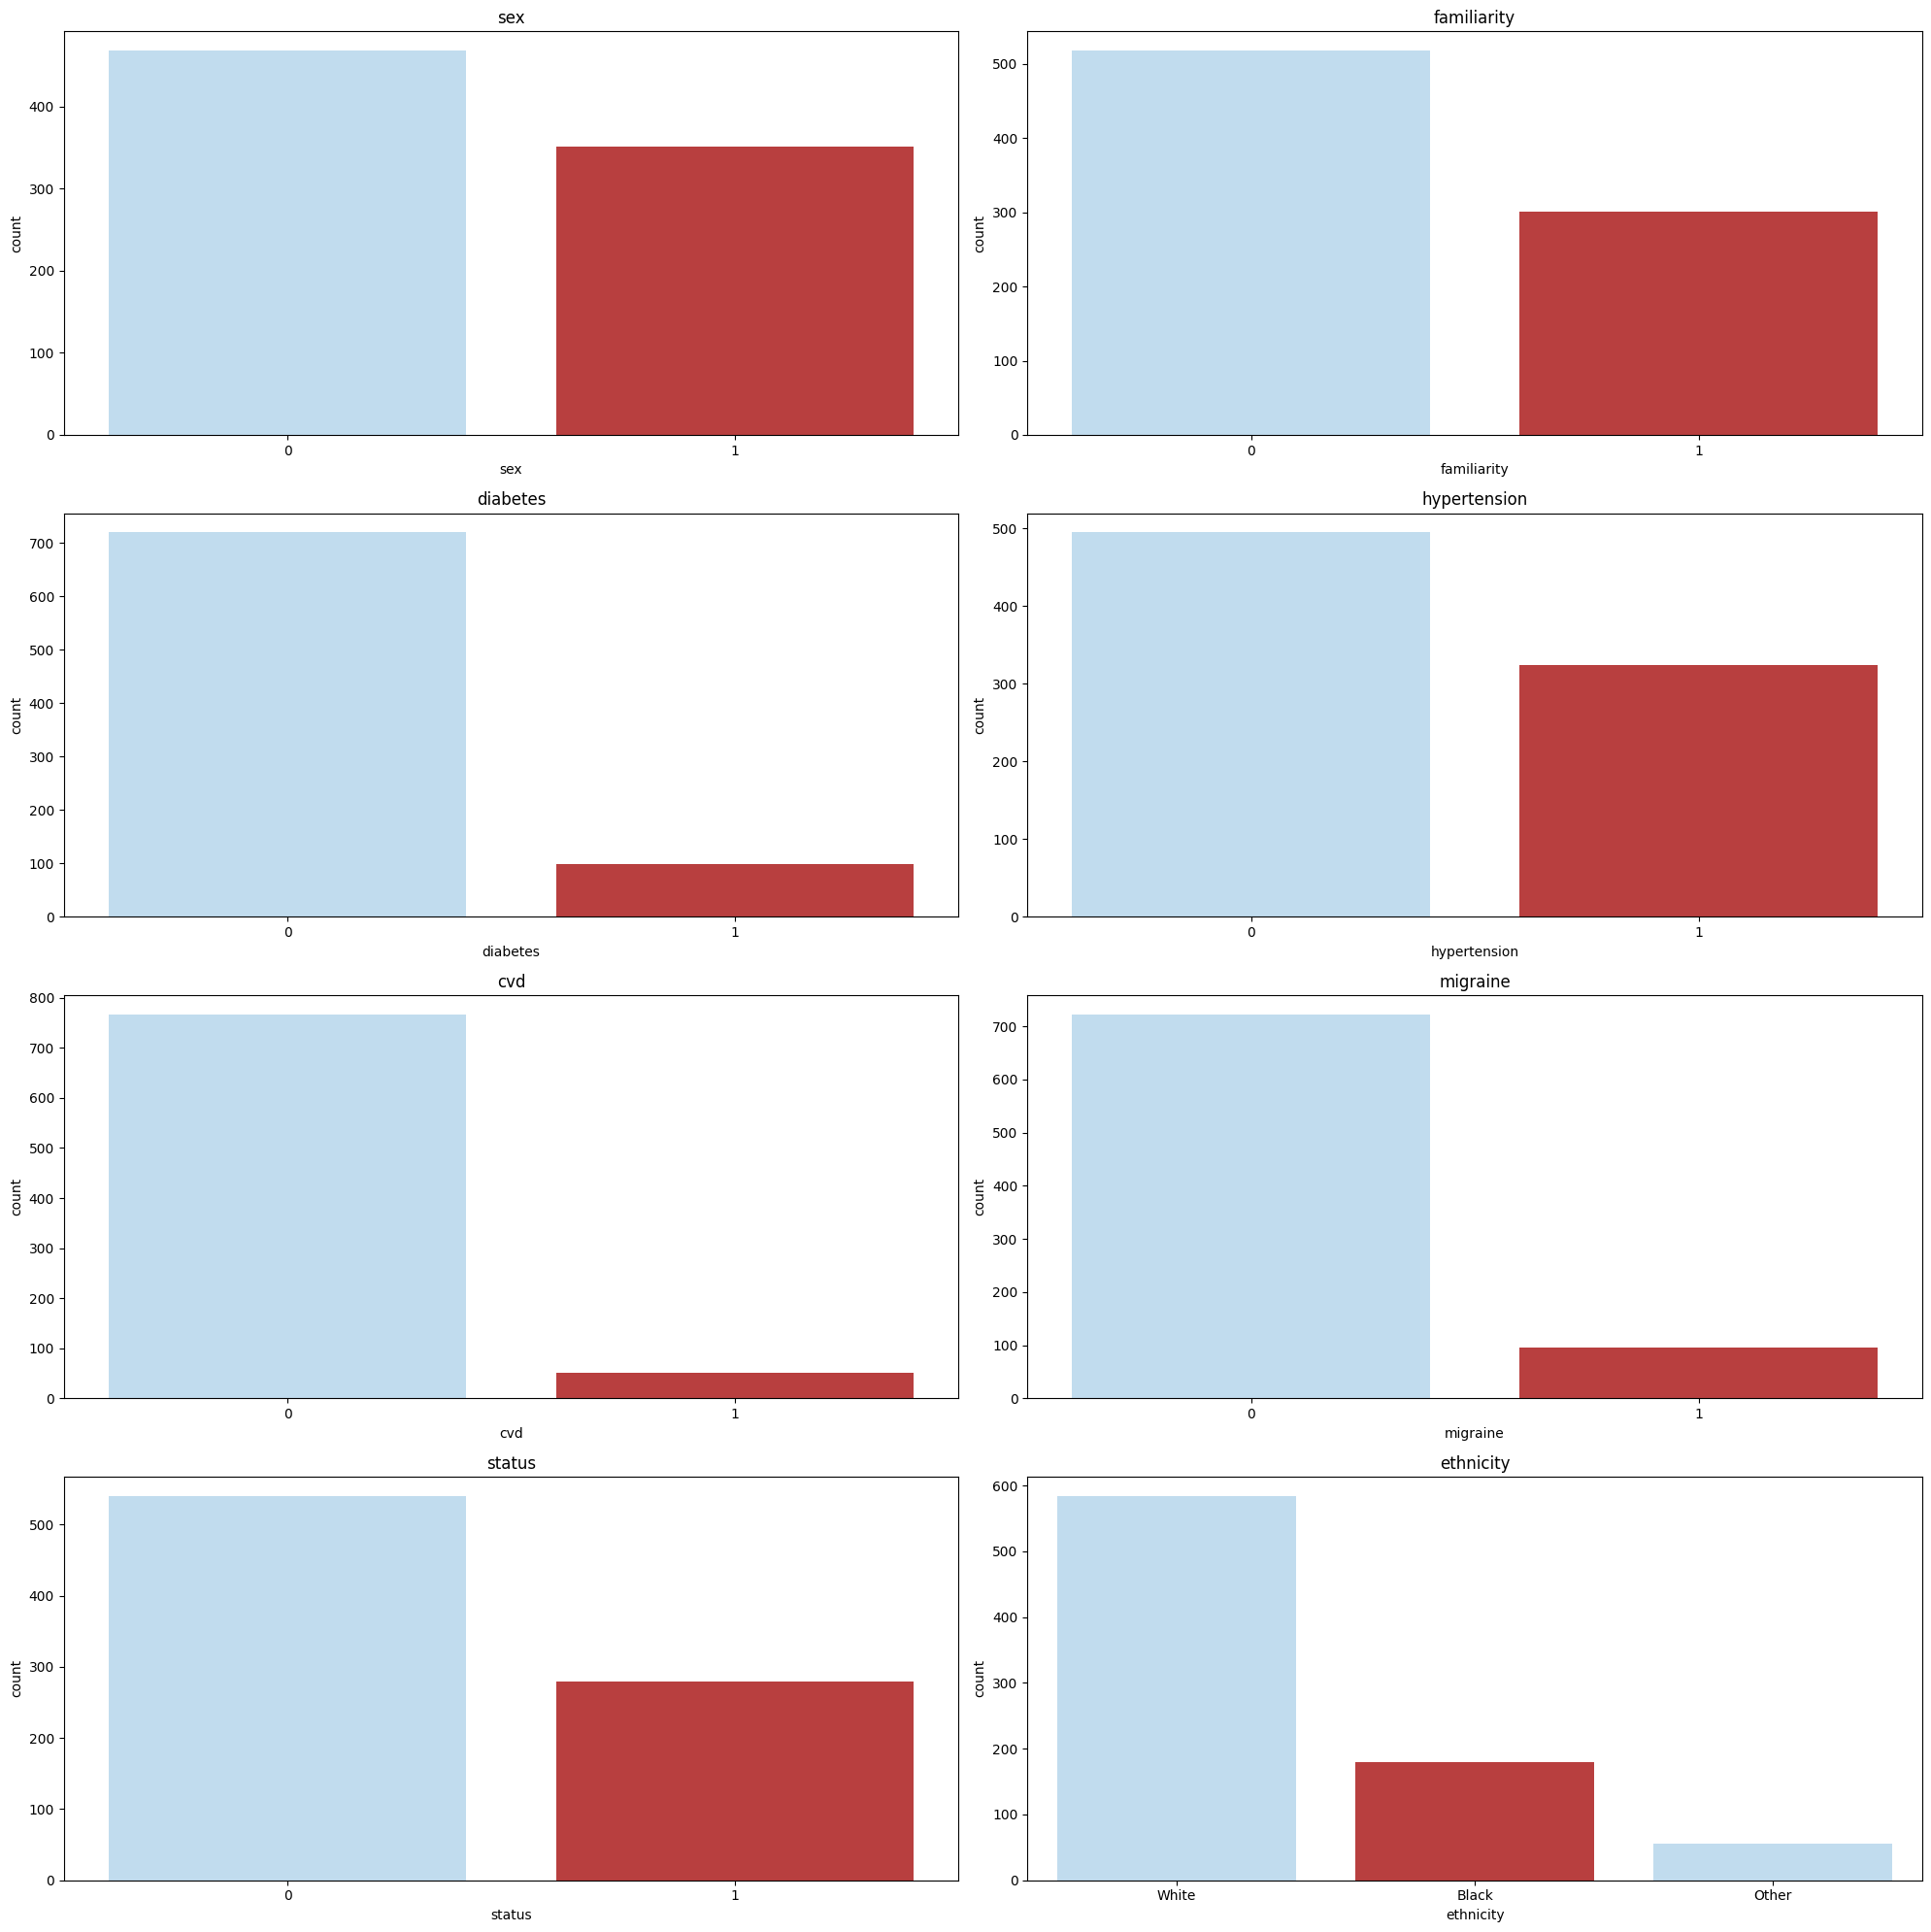

In [114]:
fig, ax = plt.subplots(nrows = 4,ncols = 2,figsize = (20,20))

ax = ax.flatten()
for i in range(len(cat_vars)):
    sns.countplot(data=df, x=cat_vars[i], palette=colors, hue=cat_vars[i], legend=False, ax=ax[i])
    title = cat_vars[i]
    ax[i].set_title(title)
plt.tight_layout() #avoid overlap among subplots
plt.show()

## Numerical variables

In [115]:
df[num_vars].describe()

,age,base_IOP,corneal_thickness,vcdr,FUP_IOP,SD_IOP,MAX_IOP,Range_IOP,CV_IOP,time
count,819.00,819.00,819.00,819.00,819.00,819.00,819.00,819.00,819.00,819.00
mean,55.50,24.72,574.51,0.40,23.83,2.48,28.89,8.62,0.11,1204.91
std,9.96,2.85,38.59,0.17,3.03,0.95,2.99,3.17,0.04,1112.22
min,26.90,18.03,467.01,0.00,11.71,0.03,21.42,0.02,0.00,56.37
25%,48.50,22.68,547.74,0.28,21.83,1.77,26.84,6.45,0.08,340.38
50%,55.79,24.69,576.48,0.41,23.93,2.47,28.66,8.59,0.10,772.28
75%,62.32,26.77,601.43,0.51,25.86,3.11,30.83,10.66,0.13,1754.61
max,93.29,33.50,680.58,0.91,34.10,5.68,38.54,20.57,0.29,3650.00


In [116]:
#Descriptive Statistics of Numerical Variables for Status=0 Group
df[df['status'] == 0][num_vars].describe()


,age,base_IOP,corneal_thickness,vcdr,FUP_IOP,SD_IOP,MAX_IOP,Range_IOP,CV_IOP,time
count,540.00,540.00,540.00,540.00,540.00,540.00,540.00,540.00,540.00,540.00
mean,55.50,24.32,574.50,0.40,23.21,2.39,28.31,8.35,0.10,1474.99
std,9.87,2.70,39.60,0.18,2.83,0.94,2.85,3.14,0.04,1192.55
min,26.90,18.03,467.68,0.01,11.71,0.03,21.42,0.02,0.00,56.37
25%,48.65,22.37,546.47,0.27,21.42,1.75,26.32,6.33,0.07,464.63
50%,55.85,24.40,577.33,0.40,23.37,2.39,28.05,8.33,0.10,1096.28
75%,62.33,26.17,602.28,0.51,25.13,2.98,30.28,10.33,0.13,2277.51
max,93.29,32.46,678.13,0.91,31.34,4.95,38.54,20.57,0.29,3650.00


In [117]:
#Descriptive Statistics of Numerical Variables for Status=1 Group
df[df['status'] == 1][num_vars].describe()

,age,base_IOP,corneal_thickness,vcdr,FUP_IOP,SD_IOP,MAX_IOP,Range_IOP,CV_IOP,time
count,279.00,279.00,279.00,279.00,279.00,279.00,279.00,279.00,279.00,279.00
mean,55.49,25.48,574.53,0.41,25.02,2.65,30.02,9.14,0.11,682.18
std,10.15,2.99,36.64,0.17,3.06,0.96,2.95,3.15,0.04,683.09
min,27.95,18.18,467.01,0.00,17.47,0.39,23.76,1.04,0.01,201.00
25%,48.44,23.64,550.24,0.29,23.07,1.90,27.72,6.83,0.08,273.00
50%,55.77,25.41,573.66,0.42,25.06,2.66,29.68,8.99,0.10,398.00
75%,62.17,27.50,600.03,0.53,27.13,3.32,32.05,11.33,0.13,812.50
max,87.82,33.50,680.58,0.79,34.10,5.68,38.17,17.40,0.26,3644.00


###Histograms

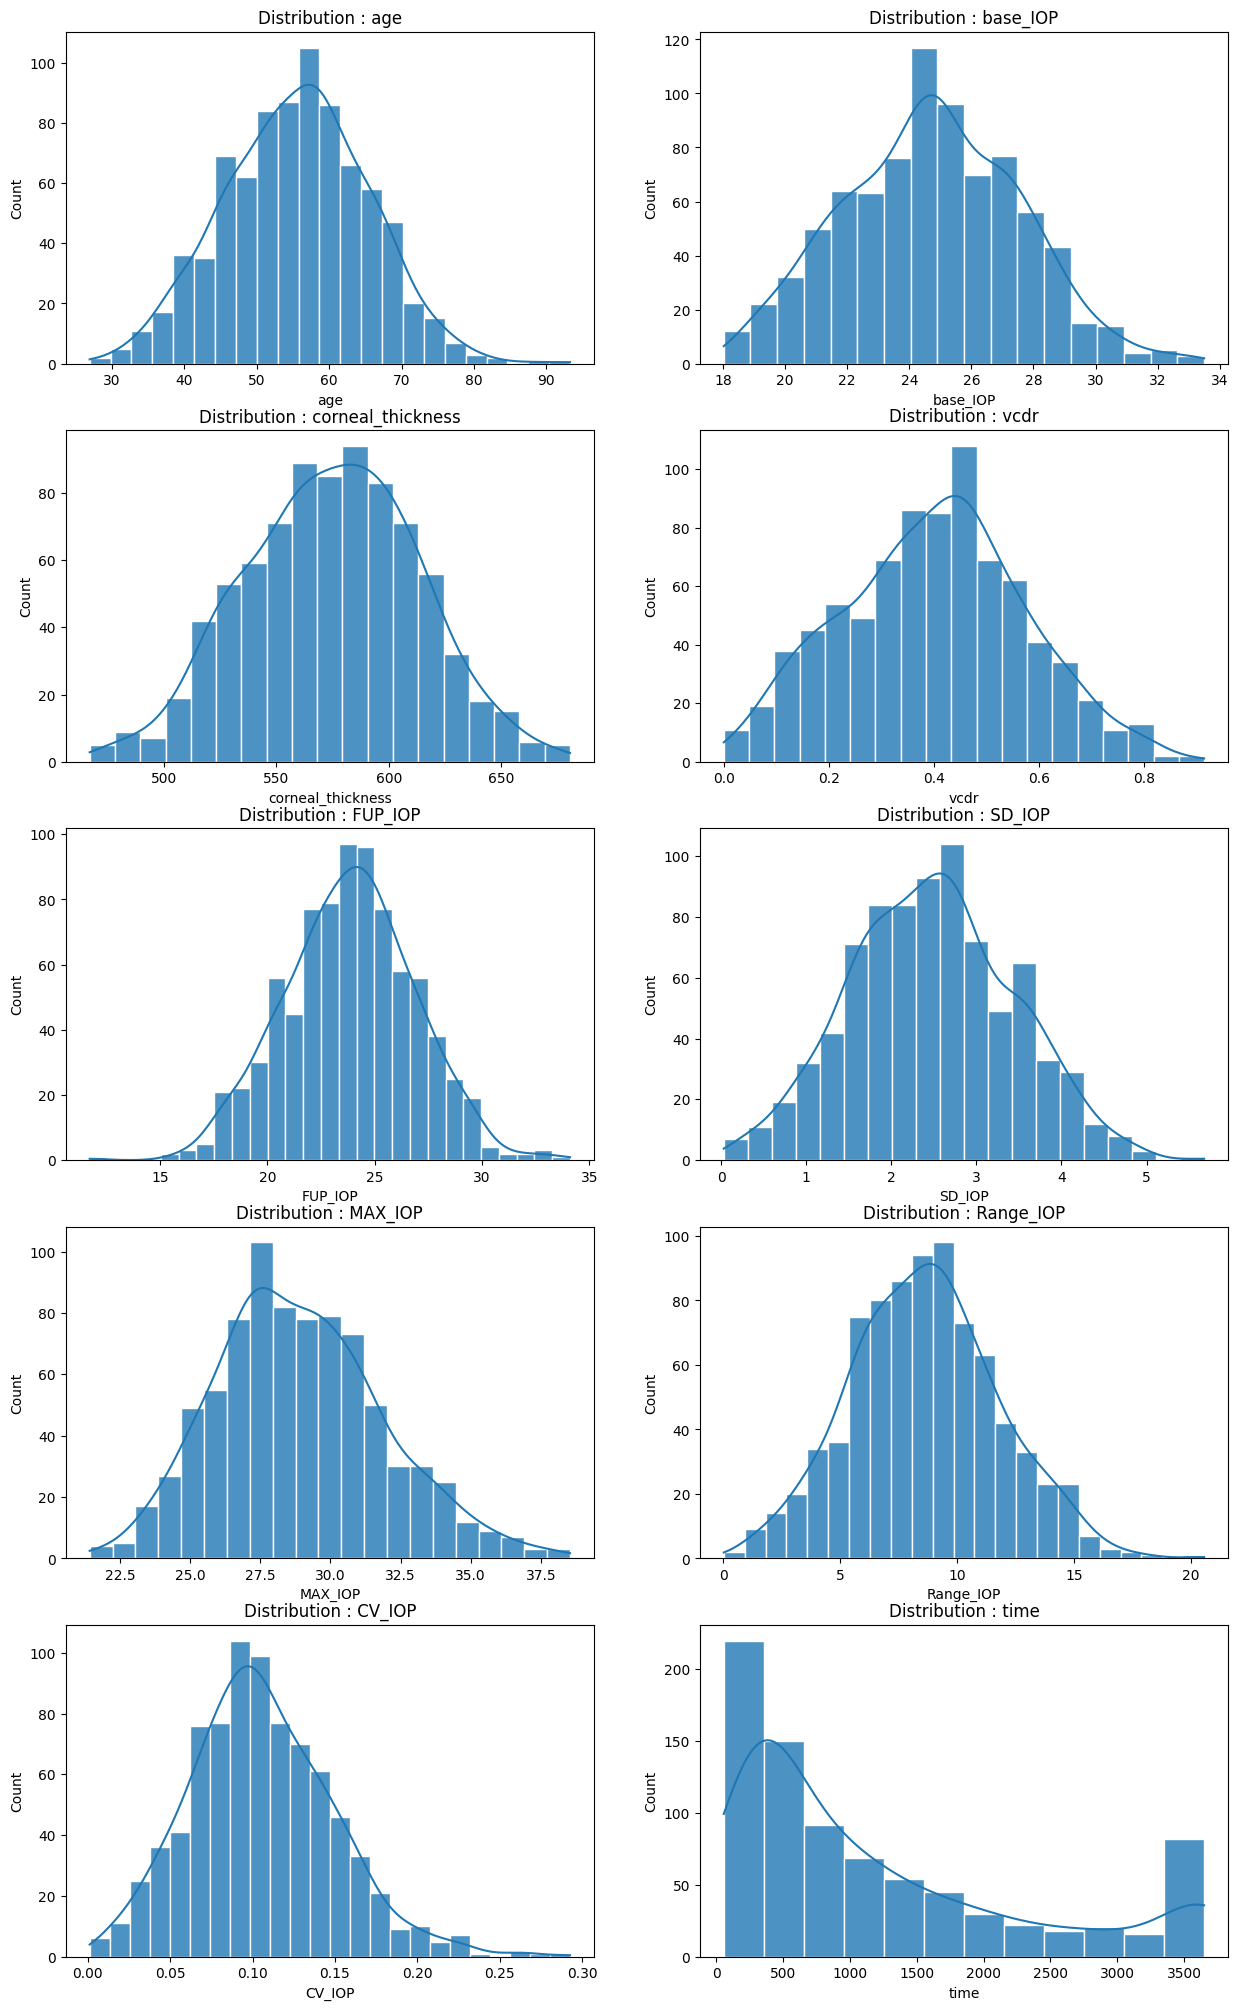

In [118]:
nrows = 5
ncols = 2

fig, ax = plt.subplots(nrows=nrows, ncols=ncols,figsize = (15,25))
for i in range(len(num_vars)):
    plt.subplot(nrows, ncols, i+1)
    sns.histplot(
      data=df, x=num_vars[i], kde=True,
      alpha=.8, edgecolor=(1, 1, 1)
    )
    title = 'Distribution : ' + num_vars[i]
    plt.title(title)
plt.show()

### Kurtosis and skeweness

In [119]:
results = []

for n in num_vars:
    k = kurtosis(df[n])
    s = skew(df[n])
    results.append({'variable': n, 'kurtosis': k, 'skewness': s})

ks_df = pd.DataFrame(results)

ks_df

,variable,kurtosis,skewness
0,age,-0.06,0.03
1,base_IOP,-0.27,0.10
2,corneal_thickness,-0.26,-0.06
3,vcdr,-0.39,0.05
4,FUP_IOP,0.14,-0.01
5,SD_IOP,-0.29,0.09
6,MAX_IOP,0.00,0.37
7,Range_IOP,-0.04,0.16
8,CV_IOP,0.62,0.49
9,time,-0.07,1.09


### Boxplots

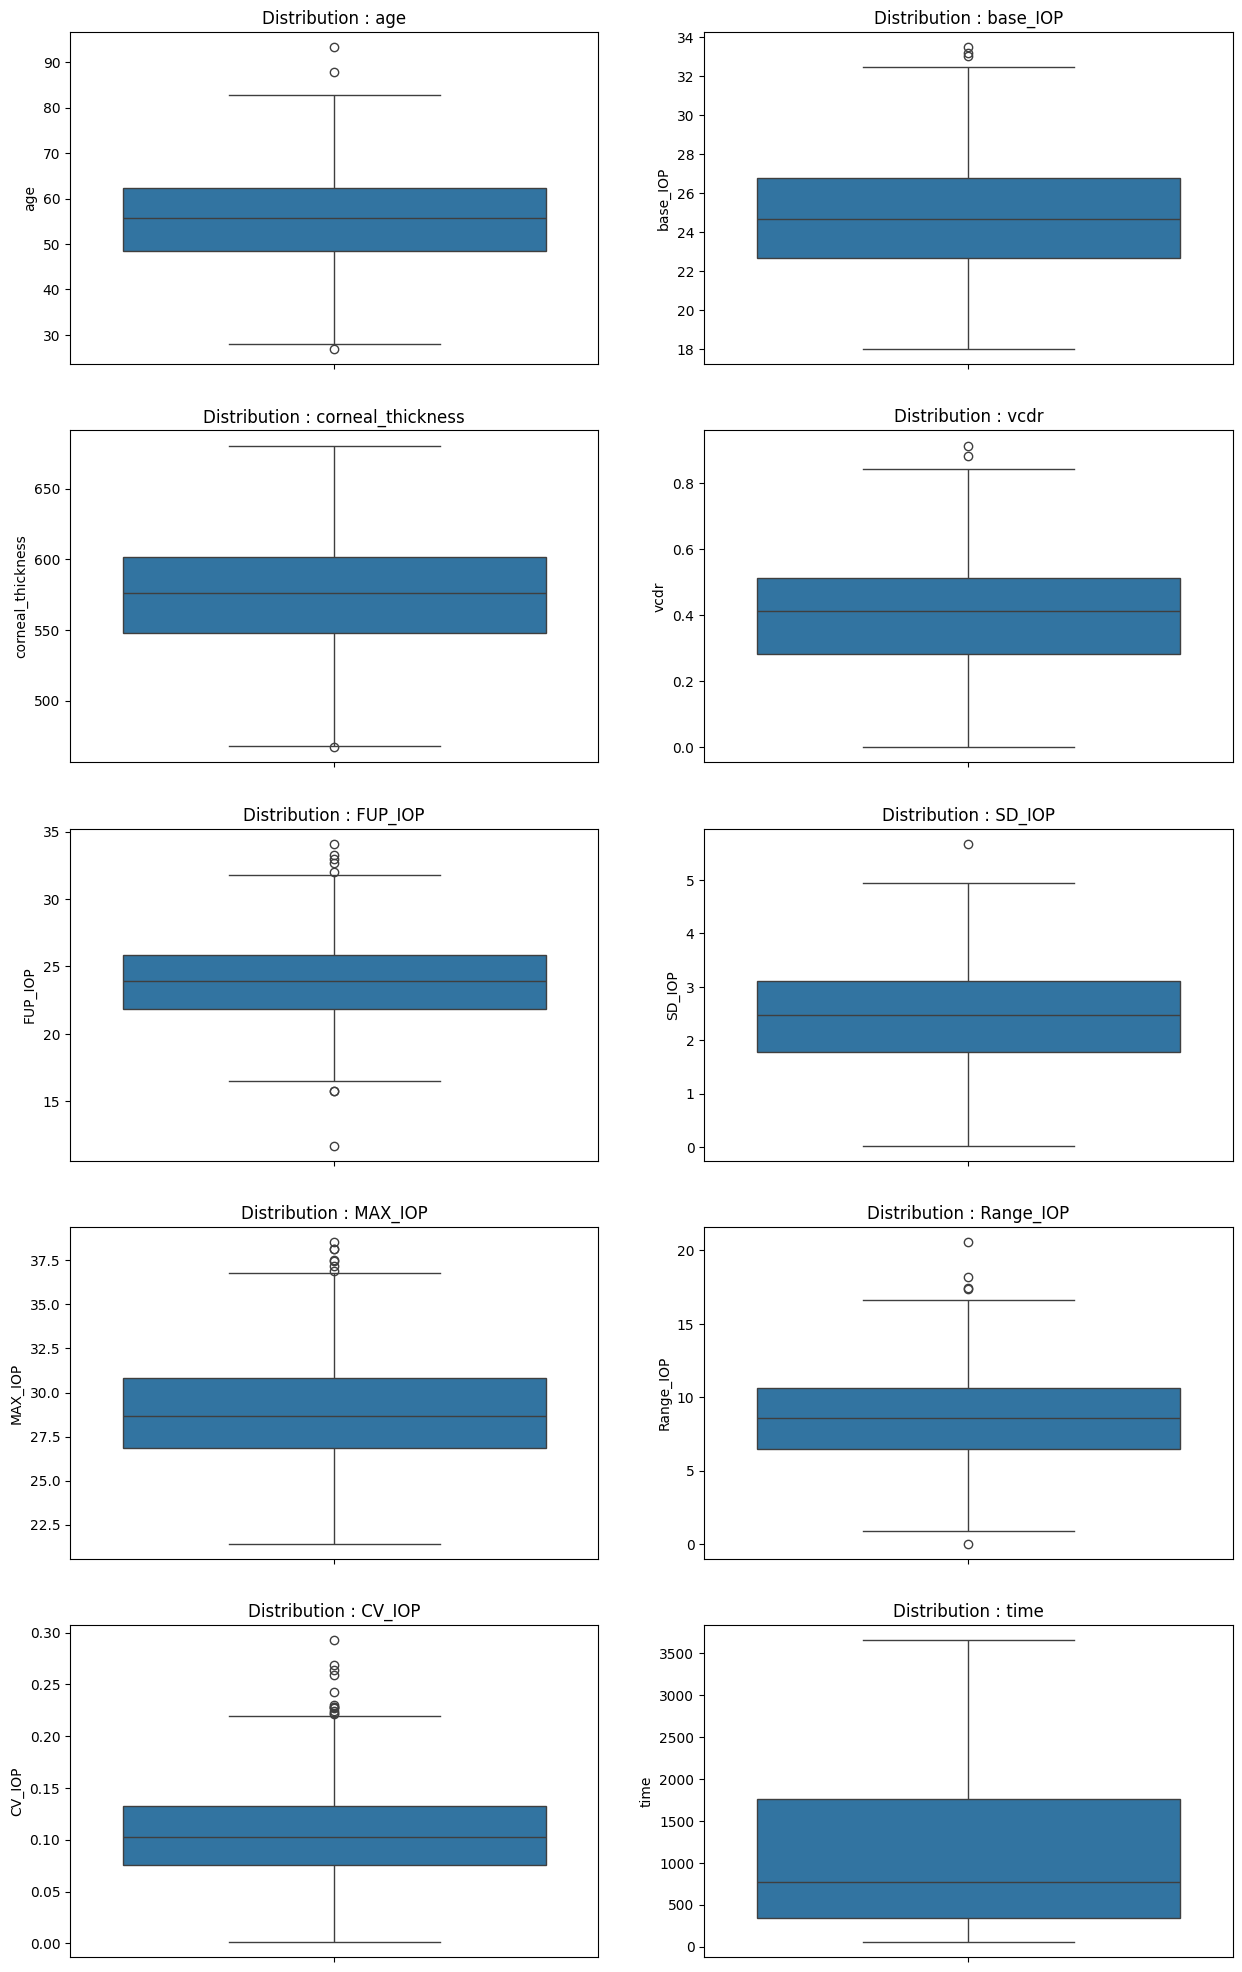

In [120]:
fig, ax = plt.subplots(nrows = 5,ncols = 2,figsize = (15,25))
for i in range(len(num_vars)):
    plt.subplot(5,2,i+1)
    sns.boxplot(data=df, y=num_vars[i])
    title = 'Distribution : ' + num_vars[i]
    plt.title(title)
plt.show()

### Correlation Matrix

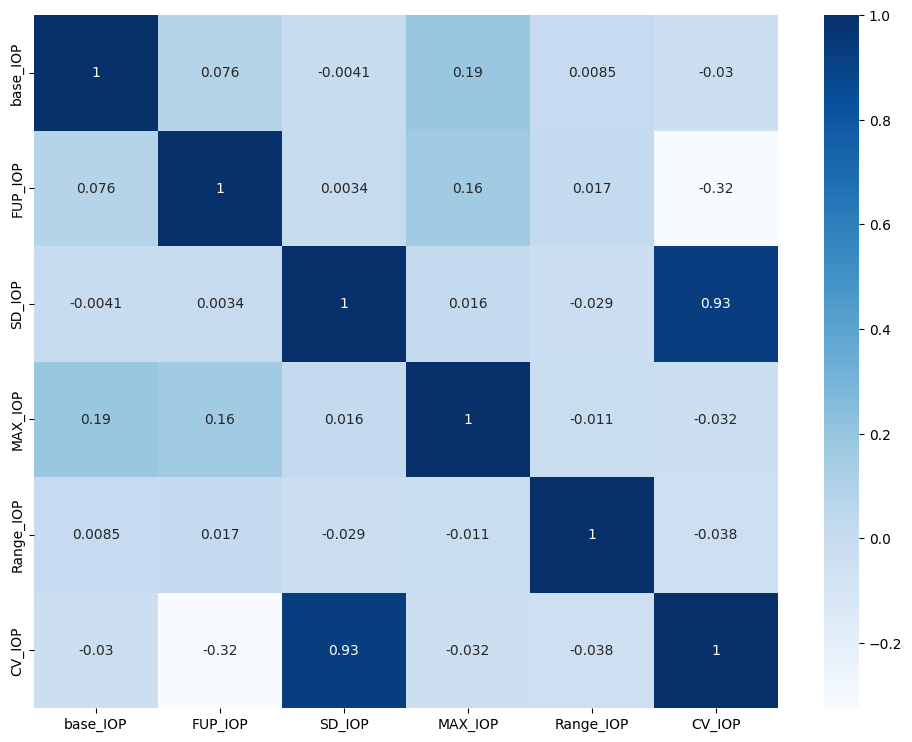

In [121]:
IOP_metrics=['base_IOP', 'FUP_IOP', 'SD_IOP', 'MAX_IOP', 'Range_IOP', 'CV_IOP']
corrmat = df[IOP_metrics].corr()
plt.figure(figsize=(12,9))
sns.heatmap(corrmat, cmap="Blues",annot=True);

# **Kaplan-Maier Curves**

$ S(t) = P(T > t) $ is the Survival function

Text(0.5, 1.0, 'Kaplan-Meier Survival Curve')

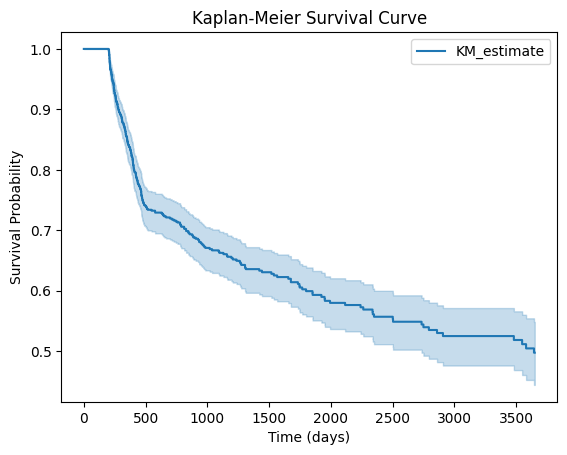

In [122]:
kmf = KaplanMeierFitter()
kmf.fit(durations = df['time'], event_observed = df['status'])
kmf.plot(ci_show=True)
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.title('Kaplan-Meier Survival Curve')

In [123]:
kmf.survival_function_

,KM_estimate
timeline,
0.00,1.00
56.37,1.00
57.02,1.00
60.29,1.00
60.98,1.00
...,...
3555.07,0.51
3580.00,0.50
3636.25,0.50


In [124]:
#Median time to progression to POAG, with confidence intervals
print('Meadian time to progression to POAG:', kmf.median_survival_time_)
print('\n\n')
print(median_survival_times(kmf.confidence_interval_))

Meadian time to progression to POAG: 3644.0



      KM_estimate_lower_0.95  KM_estimate_upper_0.95
0.50                 2734.00                     inf


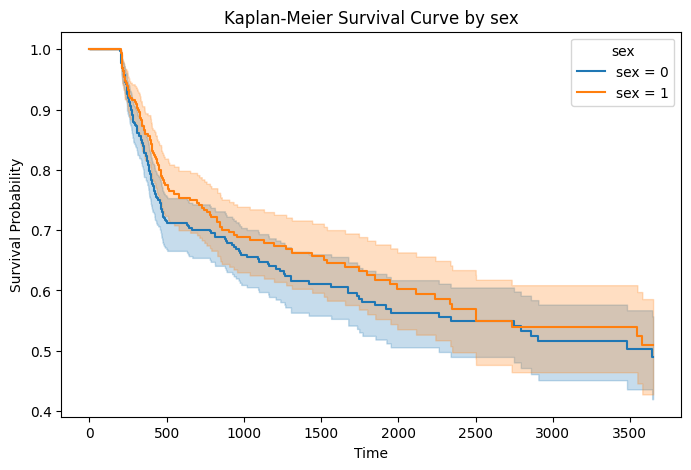

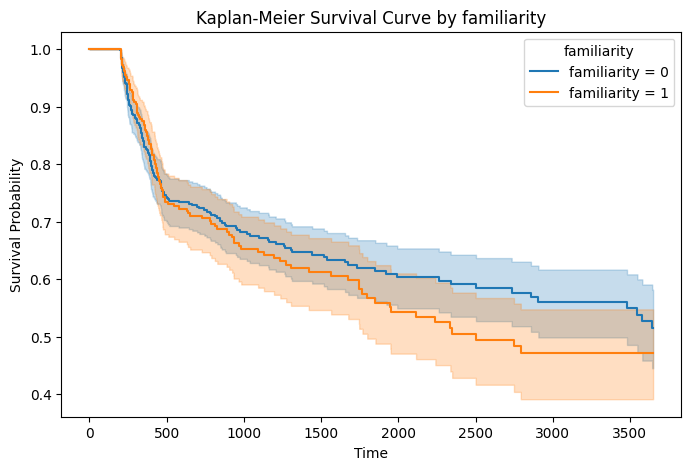

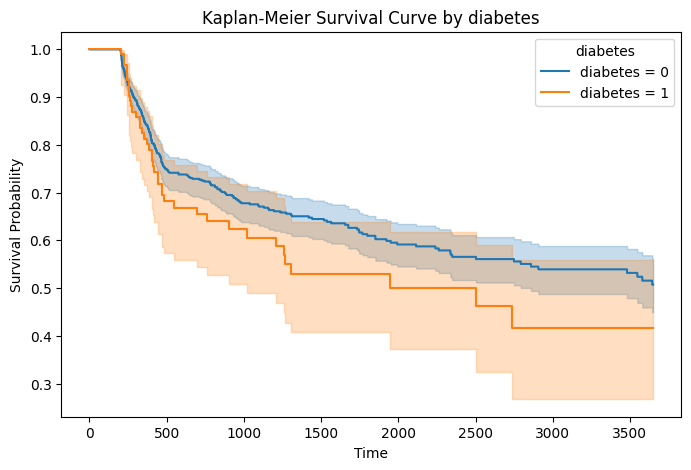

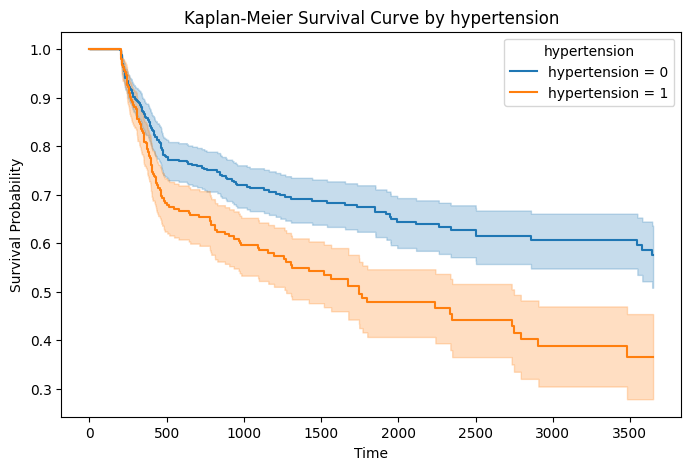

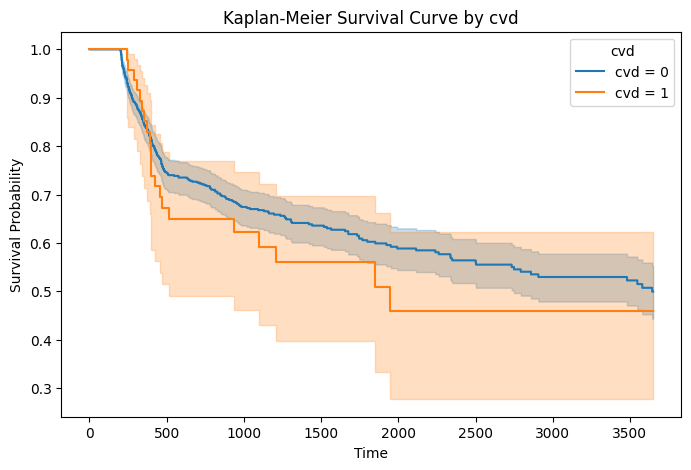

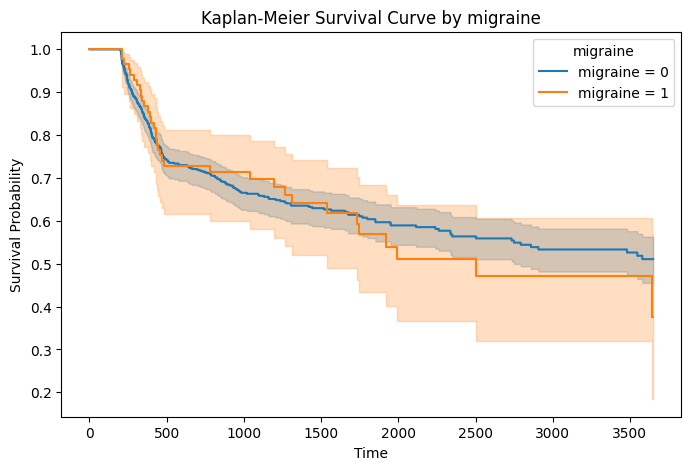

In [125]:
#Kaplan-Maier Curves by binary categorical variables

categorical_vars = ['sex', 'familiarity', 'diabetes', 'hypertension', 'cvd', 'migraine']

for var in categorical_vars:
    fig, ax = plt.subplots(figsize=(8, 5))
    unique_categories = df[var].dropna().unique()

    for category in unique_categories:
        subset = (df[var] == category)

        kmf = KaplanMeierFitter()
        kmf.fit(
            durations=df.loc[subset, 'time'],
            event_observed=df.loc[subset, 'status'],
            label=f"{var} = {category}"
        )
        kmf.plot_survival_function(ax=ax)

    # Set plot titles and labels
    plt.title(f"Kaplan-Meier Survival Curve by {var}")
    plt.xlabel("Time")
    plt.ylabel("Survival Probability")
    plt.legend(title=var)
    plt.show()

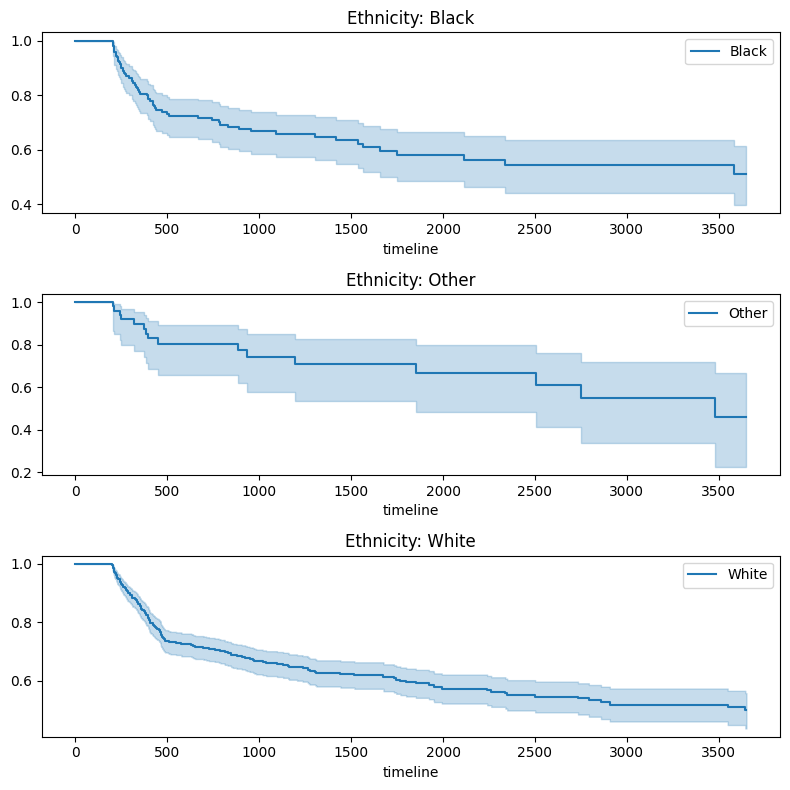

In [126]:
#KM divided by ethnicity
ethnicity_values = np.sort(df['ethnicity'].unique())

plt.figure(figsize=(8,8))

for i, ethnicity in enumerate(ethnicity_values):
    ax = plt.subplot(3, 1, i+1)
    ix = df['ethnicity'] == ethnicity
    kmf.fit(df.loc[ix]['time'], df.loc[ix]['status'], label=ethnicity)
    kmf.plot_survival_function(ax=ax, legend=True)


    plt.title('Ethnicity: ' + str(ethnicity))
plt.tight_layout()

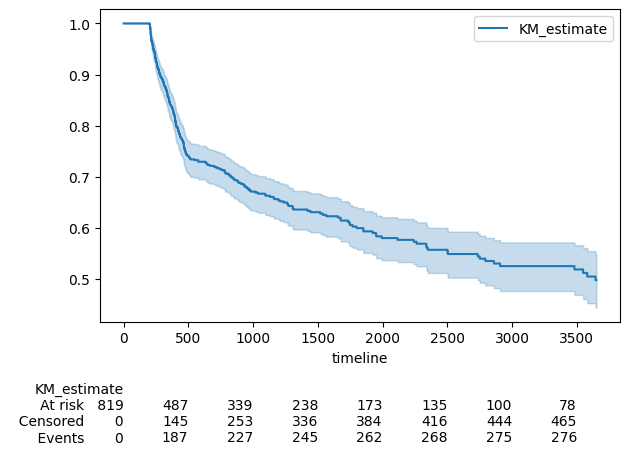

In [127]:
#KM including a table
kmf = KaplanMeierFitter().fit(df['time'], df['status'])
kmf.plot_survival_function(at_risk_counts=True)
plt.tight_layout()

# **Nelson-Aalen estimation cumulative hazard function**

Text(0.5, 1.0, 'Nelson-Aalen Cumulative Hazard Curve')

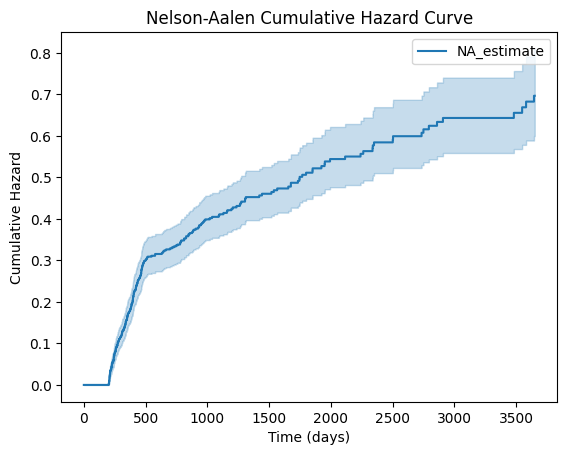

In [128]:
naf = NelsonAalenFitter()

naf.fit(df['time'],event_observed=df['status'])
naf.plot_cumulative_hazard()
plt.xlabel('Time (days)')
plt.ylabel('Cumulative Hazard')
plt.title('Nelson-Aalen Cumulative Hazard Curve')

In [129]:
naf.cumulative_hazard_

,NA_estimate
timeline,
0.00,0.00
56.37,0.00
57.02,0.00
60.29,0.00
60.98,0.00
...,...
3555.07,0.67
3580.00,0.68
3636.25,0.68


# **Log-rank test**

In [130]:
#Log-Rank Tests on binary categorical variables to compare survival distributions
categorical_vars = ['sex', 'familiarity', 'diabetes', 'hypertension', 'cvd', 'migraine']
T = df['time']
E = df['status']

for var in categorical_vars:
    group_1 = (df[var] == 0)
    group_2 = (df[var] == 1)
    # Perform log-rank test
    results = logrank_test(T[group_1], T[group_2], E[group_1], E[group_2])
    # Print the results
    print(f"\nLog-Rank Test for {var}:")
    results.print_summary()


Log-Rank Test for sex:


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           1.10 0.29      1.76


Log-Rank Test for familiarity:


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.68 0.41      1.29


Log-Rank Test for diabetes:


...

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          17.53 <0.005     15.11


Log-Rank Test for cvd:


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.70 0.40      1.32


Log-Rank Test for migraine:


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.12 0.73      0.46

Compare survival functions of K (>2) groups

$$H_0: S_1() = S_2() = ... = S_K()$$
$$H_1: \text{survival curves are different}$$

In [131]:
#Log-Rank Test for survival distributions across ethnicity groups
results = multivariate_logrank_test(df['time'], df['ethnicity'], df['status'])
results.print_summary()

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           0.51 0.77      0.37

# **Cox Model**

## *First model with all variables*

In [132]:
#OneHotEncode categorical var
df_enc = pd.get_dummies(df, columns=['ethnicity'], dtype=int, drop_first=True)

#Standardize numerical var
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_enc[['age', 'base_IOP', 'corneal_thickness', 'vcdr', 'FUP_IOP', 'SD_IOP', 'MAX_IOP', 'Range_IOP', 'CV_IOP']] = scaler.fit_transform(df_enc[['age', 'base_IOP', 'corneal_thickness', 'vcdr', 'FUP_IOP', 'SD_IOP', 'MAX_IOP', 'Range_IOP', 'CV_IOP']])

#Drop CV_IOP
df_enc = df_enc.drop(columns=['CV_IOP'])

In [133]:
df_enc

,age,base_IOP,corneal_thickness,vcdr,FUP_IOP,SD_IOP,MAX_IOP,Range_IOP,sex,familiarity,diabetes,hypertension,cvd,migraine,time,status,ethnicity_Other,ethnicity_White
0,0.32,0.50,-0.28,-1.36,0.51,-1.52,-0.80,0.91,0,0,0,0,0,0,459.36,0,0,1
1,-0.98,-0.03,0.32,-0.39,0.64,-0.73,-0.79,1.48,0,0,0,1,0,0,274.00,1,0,1
2,-0.91,0.35,-0.43,0.54,-0.33,-1.01,1.61,-1.67,1,0,0,0,0,0,308.71,0,0,1
3,0.26,-0.27,-1.15,0.09,-0.17,-0.33,-1.13,-0.16,0,0,0,0,0,0,757.49,0,0,1
4,1.38,-1.25,0.56,1.21,-0.45,-0.13,-0.52,1.47,1,0,1,0,0,0,3650.00,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
814,-0.23,-1.79,1.15,0.11,-1.02,-0.44,0.62,-1.18,1,1,0,1,0,0,3650.00,0,0,0
815,0.52,-0.86,0.16,-0.95,-0.90,0.28,0.56,-0.65,1,0,0,0,0,0,204.00,1,1,0
816,-1.00,0.65,-0.37,-0.92,0.56,-0.68,-0.78,0.23,0,1,0,0,0,1,400.00,1,0,1
817,0.09,0.75,0.30,0.18,0.33,-1.36,0.34,-0.89,0,0,0,1,0,0,461.00,1,0,1


In [134]:
df_enc.columns

Index(['age', 'base_IOP', 'corneal_thickness', 'vcdr', 'FUP_IOP', 'SD_IOP',
       'MAX_IOP', 'Range_IOP', 'sex', 'familiarity', 'diabetes',
       'hypertension', 'cvd', 'migraine', 'time', 'status', 'ethnicity_Other',
       'ethnicity_White'],
      dtype='object')

In [135]:
#fit the model
cph = CoxPHFitter()
cph.fit(df_enc, duration_col = 'time', event_col = 'status')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 819 total observations, 540 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 819
number of events observed = 279
   partial log-likelihood = -1591.02
         time fit was run = 2024-12-17 20:25:12 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
age                0.05      1.05      0.06           -0.07            0.17                0.94                1.18
base_IOP           0.34      1.41      0.06            0.23            0.46                1.25                1.58
corneal_thickness  0.01      1.01      0.06           -0.11            0.13                0.89                1.14
vcdr               0.02      1.02      0.06           -0.11            0.14                0.90                1.15
FUP_IOP            0.56      1.75      0.06            0.44            0.69                1.55                1.99
SD_IOP             0.33      1.38      0.06            0.21            0.45                1.23                1.56
MAX_IOP            0.48      1.62      0.06            0.36            0.61                1.43                1.84
Range_IOP          0.30      1.35      0.06            0.18            0.43                1.20                1.53
sex               -0.23      0.80      0.12           -0.47            0.01                0.62                1.01
familiarity        0.18      1.19      0.13           -0.07            0.42                0.93                1.53
diabetes           0.08      1.08      0.18           -0.26            0.43                0.77                1.53
hypertension       0.49      1.63      0.12            0.25            0.73                1.28                2.07
cvd                0.06      1.06      0.23           -0.39            0.52                0.67                1.68
migraine           0.11      1.11      0.19           -0.26            0.47                0.77                1.61
ethnicity_Other   -0.20      0.82      0.29           -0.76            0.36                0.47                1.44
ethnicity_White   -0.12      0.89      0.15           -0.41            0.17                0.66                1.19

                   cmp to     z      p  -log2(p)
covariate                                       
age                  0.00  0.85   0.40      1.34
base_IOP             0.00  5.76 <0.005     26.84
corneal_thickness    0.00  0.17   0.86      0.21
vcdr                 0.00  0.24   0.81      0.31
FUP_IOP              0.00  8.73 <0.005     58.40
SD_IOP               0.00  5.30 <0.005     23.01
MAX_IOP              0.00  7.47 <0.005     43.46
Range_IOP            0.00  4.83 <0.005     19.46
sex                  0.00 -1.84   0.07      3.94
familiarity          0.00  1.42   0.16      2.68
diabetes             0.00  0.46   0.65      0.63
hypertension         0.00  3.94 <0.005     13.61
cvd                  0.00  0.27   0.79      0.34
migraine             0.00  0.57   0.57      0.81
ethnicity_Other      0.00 -0.69   0.49      1.03
ethnicity_White      0.00 -0.81   0.42      1.25
---
Concordance = 0.76
Partial AIC = 3214.05
log-likelihood ratio test = 255.26 on 16 df
-log2(p) of ll-ratio test = 147.38

<Axes: xlabel='HR (95% CI)'>

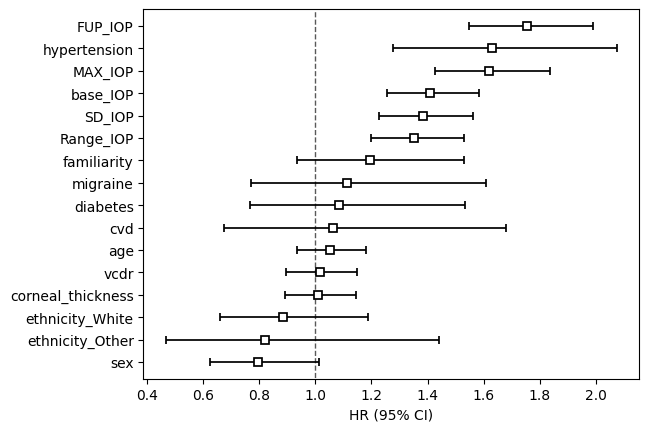

In [136]:
cph.plot(hazard_ratios=True)

### Cross Validation

In [137]:
from lifelines.utils import k_fold_cross_validation
features = df_enc.columns.to_list().copy()
scores = k_fold_cross_validation(cph, df_enc[features], 'time', event_col='status', k=10, scoring_method="concordance_index", seed=1234)
scores

[0.8165596002855103,
 0.7900928792569659,
 0.6981566820276498,
 0.717391304347826,
 0.7432045779685265,
 0.6594955489614244,
 0.8048433048433048,
 0.6924110141034251,
 0.775092936802974,
 0.7184813753581661]

In [138]:
print(np.mean(scores), np.std(scores))

0.7415729223955773 0.05026242295802246


## *Forward and Backward Selection*

In [139]:
# Selected variables
selected_columns = ['age', 'base_IOP', 'corneal_thickness', 'vcdr', 'FUP_IOP', 'SD_IOP',
                    'MAX_IOP', 'Range_IOP', 'sex', 'hypertension', 'time', 'status']

df_enc_2 = df_enc[selected_columns]

In [140]:
def forward_selection(X, T, E):
    # Start with the full set of features
    remaining_features = X.columns.tolist()
    remaining_features.remove(T)
    remaining_features.remove(E)
    features = []

    # Store results for each model size
    metrics = []

    # Step 1: Iteratively add features
    for i in tqdm(range(len(remaining_features))):
        best_features = None
        removed_feature = None
        best_metric_value = -float("inf")  # Initialize for finding best model in this iteration
        best_model_metrics = None

        # Step 2: Evaluate all remaining features
        for feature in remaining_features:
            current_features = features + [feature]  # Current set of features with the candidate
            X_current = X[current_features + [T, E]]
            try:
              scores = k_fold_cross_validation(cph, X_current, T, event_col=E, k=10, scoring_method="concordance_index")
            except:
              print('Error in fitting with features: ', current_features)
              continue
            mean_metric_value = np.mean(scores)

            # Update if this feature is the best so far
            if mean_metric_value > best_metric_value:
                best_features = current_features
                removed_feature = feature
                best_model_metrics = {'c_index':mean_metric_value}
                best_model_metrics['features'] = best_features

        features = best_features
        if removed_feature is not None:
          remaining_features.remove(removed_feature)
          metrics.append(best_model_metrics)


    # Step 3: Select the single best model
    best_criterion_value = -float("inf") # -infinite
    best_features = None

    for m in metrics:
      if m['c_index'] > best_criterion_value:
          best_criterion_value = m['c_index']
          best_features = m['features']

    summary_df = pd.DataFrame(metrics).sort_values(by='c_index', ascending=False)
    summary_df['n_features'] = summary_df['features'].apply(len)
    summary_df = summary_df[['n_features', 'features', 'c_index']] #reorder cols
    return summary_df, best_features

In [141]:
cph = CoxPHFitter()
models, best_features = forward_selection(df_enc_2, T='time', E='status')

  0%|          | 0/10 [00:00<?, ?it/s]

In [142]:
models

,n_features,features,c_index
9,10,"[hypertension, sex, Range_IOP, MAX_IOP, SD_IOP...",0.75
8,9,"[hypertension, sex, Range_IOP, MAX_IOP, SD_IOP...",0.75
5,6,"[hypertension, sex, Range_IOP, MAX_IOP, SD_IOP...",0.74
6,7,"[hypertension, sex, Range_IOP, MAX_IOP, SD_IOP...",0.74
7,8,"[hypertension, sex, Range_IOP, MAX_IOP, SD_IOP...",0.74
3,4,"[hypertension, sex, Range_IOP, MAX_IOP]",0.69
4,5,"[hypertension, sex, Range_IOP, MAX_IOP, SD_IOP]",0.69
2,3,"[hypertension, sex, Range_IOP]",0.59
1,2,"[hypertension, sex]",0.56
0,1,[hypertension],0.55


In [143]:
best_features

['hypertension',
 'sex',
 'Range_IOP',
 'MAX_IOP',
 'SD_IOP',
 'FUP_IOP',
 'vcdr',
 'corneal_thickness',
 'base_IOP',
 'age']

In [144]:
def backward_selection(X, T, E):
    # Start with the full set of features
    initial_features = X.columns.tolist()
    initial_features.remove(T)
    initial_features.remove(E)
    n_features = len(initial_features)

    # Store results for each model size
    metrics = []

    # Step 1: Fit the full model
    X_current = X[initial_features + [T, E]]
    scores = k_fold_cross_validation(cph, X_current, T, event_col=E, k=10, scoring_method="concordance_index")
    mean_metric_value = np.mean(scores)
    initial_model_metrics = {'c_index':mean_metric_value}
    initial_model_metrics['features'] = initial_features
    metrics.append(initial_model_metrics)

    features = initial_features
    # Backward selection loop
    while len(features) > 1:
        best_metric_value = -float("inf")  # Initialize for finding best model in this iteration
        best_features = None # Initialize best_features to None instead of best_combination

        # Step 2: Evaluate all models with (k-1) predictors
        for feature in features:
            remaining_features = [f for f in features if f != feature]  # All features except the current one
            X_current = X[remaining_features + [T, E]]
            scores = k_fold_cross_validation(cph, X_current, T, event_col=E, k=10, scoring_method="concordance_index")
            mean_metric_value = np.mean(scores)

            # Update if this feature is the best so far
            if mean_metric_value > best_metric_value:
                best_features = remaining_features  # Assign to best_features if condition is true
                best_model_metrics = {'c_index':mean_metric_value}
                best_model_metrics['features'] = remaining_features


        #features = best_combination # Remove this line
        features = best_features #Assign best_features to features instead of best_combination
        metrics.append(best_model_metrics) #Append metrics in the while loop


    # Step 3: Select the single best model
    best_criterion_value = -float("inf") # -infinite
    best_features = None

    for m in metrics:
      if m['c_index'] > best_criterion_value:
          best_criterion_value = m['c_index']
          best_features = m['features']

    summary_df = pd.DataFrame(metrics).sort_values(by='c_index', ascending=False)
    summary_df['n_features'] = summary_df['features'].apply(len)
    summary_df = summary_df[['n_features', 'features', 'c_index']] #reorder cols
    return summary_df, best_features

In [145]:
cph = CoxPHFitter()
models_back, best_features_back = backward_selection(df_enc_2, T='time', E='status')

In [146]:
models_back

,n_features,features,c_index
0,10,"[age, base_IOP, corneal_thickness, vcdr, FUP_I...",0.75
2,8,"[age, base_IOP, corneal_thickness, vcdr, FUP_I...",0.74
1,9,"[age, base_IOP, corneal_thickness, vcdr, FUP_I...",0.74
3,7,"[age, base_IOP, corneal_thickness, vcdr, FUP_I...",0.74
4,6,"[age, base_IOP, corneal_thickness, vcdr, FUP_I...",0.70
5,5,"[age, base_IOP, corneal_thickness, vcdr, FUP_IOP]",0.68
8,2,"[age, base_IOP]",0.61
6,4,"[age, base_IOP, corneal_thickness, vcdr]",0.61
7,3,"[age, base_IOP, corneal_thickness]",0.60
9,1,[age],0.51


In [147]:
best_features_back

['age',
 'base_IOP',
 'corneal_thickness',
 'vcdr',
 'FUP_IOP',
 'SD_IOP',
 'MAX_IOP',
 'Range_IOP',
 'sex',
 'hypertension']

### Model with selected variables

In [148]:
df_enc_3=df_enc[['age', 'base_IOP', 'corneal_thickness', 'vcdr', 'FUP_IOP', 'SD_IOP', 'MAX_IOP', 'Range_IOP', 'sex', 'hypertension', 'time', 'status']]

In [149]:
#Fit the model
cph = CoxPHFitter()
cph.fit(df_enc_3, duration_col = 'time', event_col = 'status')

<lifelines.CoxPHFitter: fitted with 819 total observations, 540 right-censored observations>

In [150]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 819 total observations, 540 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 819
number of events observed = 279
   partial log-likelihood = -1592.65
         time fit was run = 2024-12-17 20:27:10 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
age                0.05      1.05      0.06           -0.07            0.16                0.93                1.18
base_IOP           0.35      1.42      0.06            0.23            0.46                1.26                1.59
corneal_thickness  0.01      1.01      0.06           -0.11            0.13                0.89                1.14
vcdr               0.02      1.02      0.06           -0.11            0.14                0.90                1.15
FUP_IOP            0.55      1.73      0.06            0.42            0.67                1.53                1.96
SD_IOP             0.33      1.38      0.06            0.21            0.44                1.23                1.56
MAX_IOP            0.48      1.62      0.06            0.36            0.61                1.43                1.83
Range_IOP          0.30      1.35      0.06            0.18            0.42                1.19                1.53
sex               -0.22      0.80      0.12           -0.46            0.02                0.63                1.02
hypertension       0.51      1.66      0.12            0.27            0.75                1.31                2.11

                   cmp to     z      p  -log2(p)
covariate                                       
age                  0.00  0.80   0.43      1.23
base_IOP             0.00  5.93 <0.005     28.26
corneal_thickness    0.00  0.18   0.86      0.22
vcdr                 0.00  0.28   0.78      0.36
FUP_IOP              0.00  8.64 <0.005     57.34
SD_IOP               0.00  5.33 <0.005     23.31
MAX_IOP              0.00  7.58 <0.005     44.76
Range_IOP            0.00  4.81 <0.005     19.33
sex                  0.00 -1.78   0.07      3.75
hypertension         0.00  4.18 <0.005     15.08
---
Concordance = 0.76
Partial AIC = 3205.31
log-likelihood ratio test = 252.00 on 10 df
-log2(p) of ll-ratio test = 158.41

### Cross Validation

In [151]:
from lifelines.utils import k_fold_cross_validation
features = df_enc_3.columns.to_list().copy()
scores = k_fold_cross_validation(cph, df_enc_3[features], 'time', event_col='status', k=10, scoring_method="concordance_index", seed=1234)
scores

print(np.mean(scores), np.std(scores))

0.7450733832991892 0.048280450764501034


## *Penalization*

In [152]:
#Fit the model
cph = CoxPHFitter(penalizer=0.05, l1_ratio=1)
cph.fit(df_enc_3, duration_col = 'time', event_col = 'status')

<lifelines.CoxPHFitter: fitted with 819 total observations, 540 right-censored observations>

In [153]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 819 total observations, 540 right-censored observations>
             duration col = 'time'
                event col = 'status'
                penalizer = 0.05
                 l1 ratio = 1
      baseline estimation = breslow
   number of observations = 819
number of events observed = 279
   partial log-likelihood = -1667.59
         time fit was run = 2024-12-17 20:27:12 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
age                0.00      1.00      0.00           -0.00            0.00                1.00                1.00
base_IOP           0.20      1.22      0.06            0.08            0.32                1.08                1.37
corneal_thickness  0.00      1.00      0.00           -0.00            0.00                1.00                1.00
vcdr               0.00      1.00      0.00           -0.00            0.00                1.00                1.00
FUP_IOP            0.39      1.47      0.06            0.26            0.51                1.30                1.67
SD_IOP             0.15      1.16      0.06            0.03            0.27                1.03                1.31
MAX_IOP            0.35      1.43      0.06            0.23            0.48                1.26                1.61
Range_IOP          0.12      1.13      0.06            0.00            0.25                1.00                1.28
sex               -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hypertension       0.21      1.24      0.12           -0.03            0.45                0.97                1.57

                   cmp to     z      p  -log2(p)
covariate                                       
age                  0.00  0.00   1.00      0.00
base_IOP             0.00  3.29 <0.005      9.95
corneal_thickness    0.00  0.00   1.00      0.00
vcdr                 0.00  0.00   1.00      0.00
FUP_IOP              0.00  6.10 <0.005     29.81
SD_IOP               0.00  2.44   0.01      6.07
MAX_IOP              0.00  5.64 <0.005     25.84
Range_IOP            0.00  1.99   0.05      4.42
sex                  0.00 -0.00   1.00      0.00
hypertension         0.00  1.72   0.08      3.56
---
Concordance = 0.75
Partial AIC = 3355.18
log-likelihood ratio test = 102.13 on 10 df
-log2(p) of ll-ratio test = 55.44

<Axes: xlabel='HR (95% CI)'>

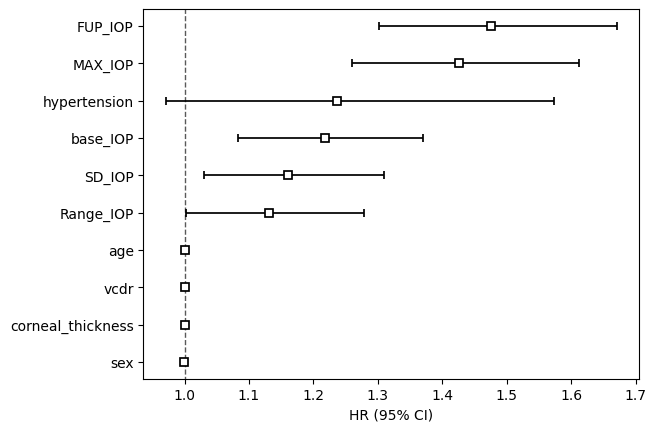

In [154]:
cph.plot(hazard_ratios=True)

### Schoenfeld's residuals and test

In [155]:
cph.check_assumptions(df_enc_3, p_value_threshold = 0.05)

Proportional hazard assumption looks okay.


[]


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.9979)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9977)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3755)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5004)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9992)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9992)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9984)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9981)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1503)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1255)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4171)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4662)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9127)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8885)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5486)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7463)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9981)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9982)'>],
 [<Axes: xlabel='rank-transformed tim

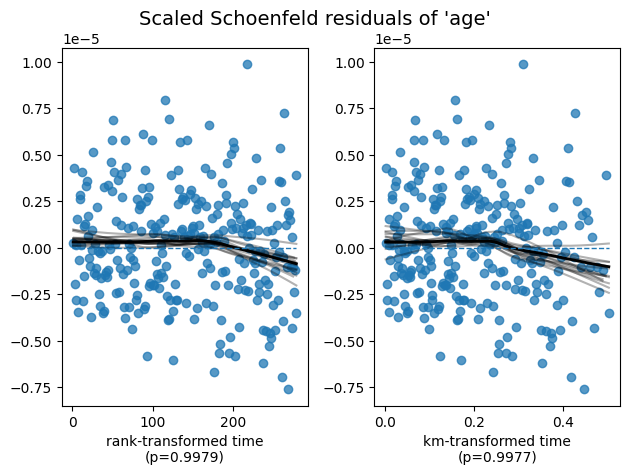

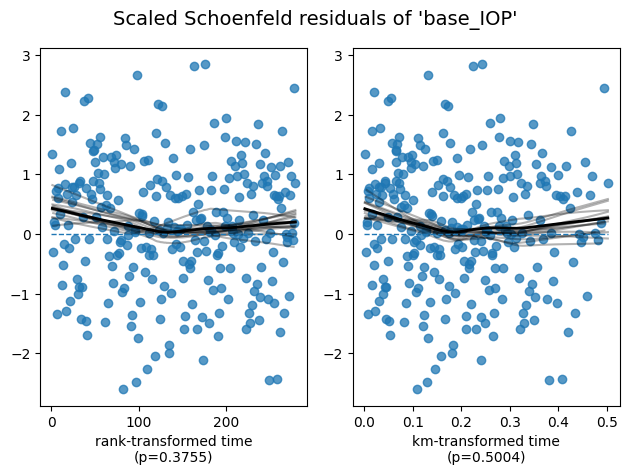

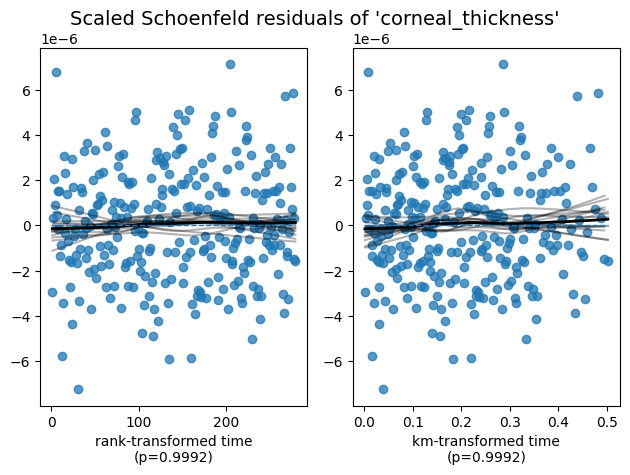

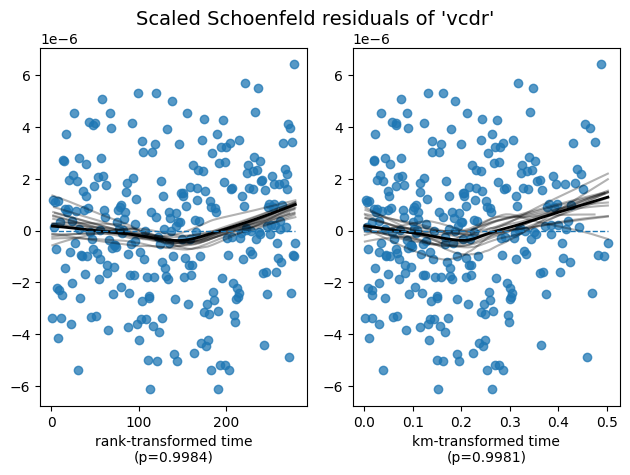

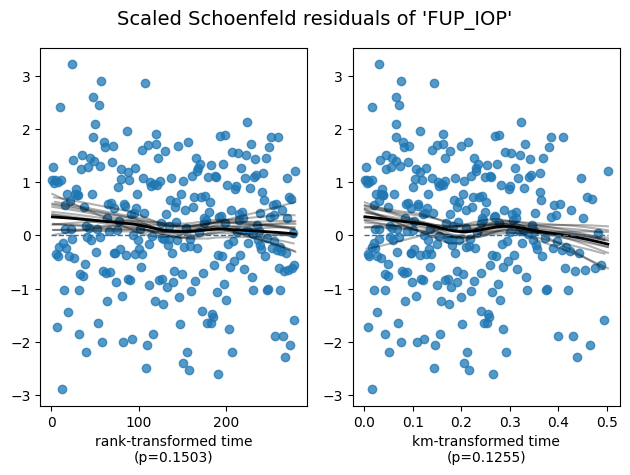

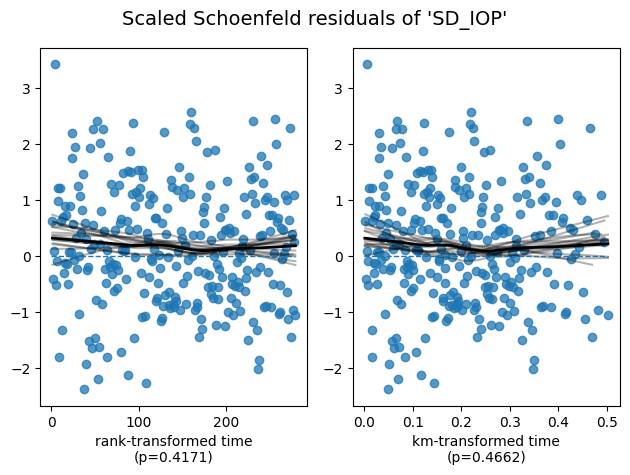

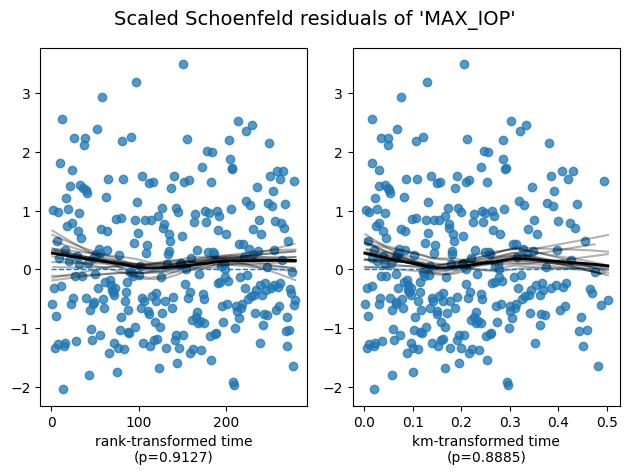

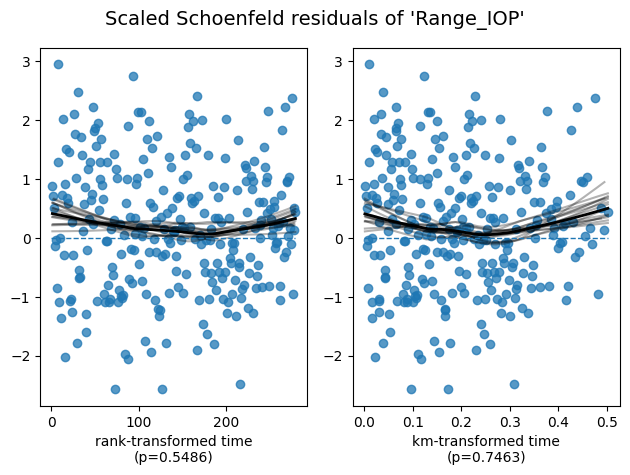

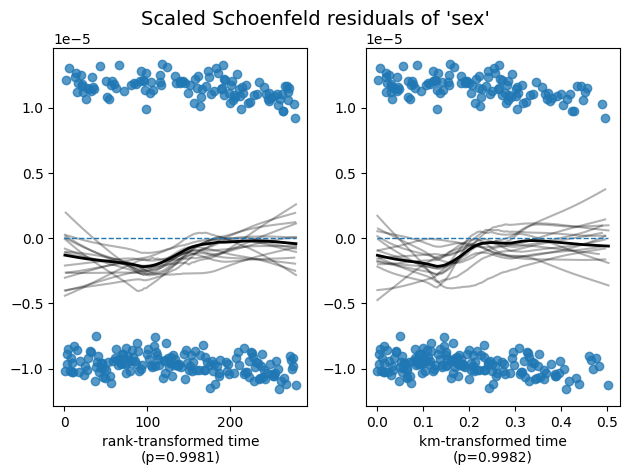

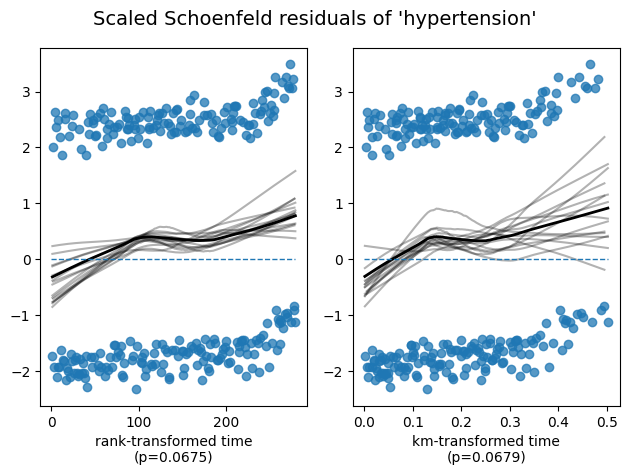

In [156]:
cph.check_assumptions(df_enc_3, p_value_threshold = 0.05, show_plots=True)

### Cross Validation

In [157]:
from lifelines.utils import k_fold_cross_validation
features = df_enc_3.columns.to_list().copy()
scores = k_fold_cross_validation(cph, df_enc_3[features], 'time', event_col='status', k=10, scoring_method="concordance_index", seed=1234)
scores

print(np.mean(scores), np.std(scores))

0.7415261002248698 0.04766834158238821


## *Model with only significant variables*

In [158]:
significant_vars = ['time', 'status', 'base_IOP', 'FUP_IOP', 'MAX_IOP', 'Range_IOP', 'SD_IOP', 'hypertension']
df_significant = df_enc_3[significant_vars]

In [159]:
#Fit the model
from lifelines import CoxPHFitter
cph = CoxPHFitter()
cph.fit(df_significant, duration_col = 'time', event_col = 'status')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 819 total observations, 540 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 819
number of events observed = 279
   partial log-likelihood = -1594.55
         time fit was run = 2024-12-17 20:27:41 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
base_IOP      0.34      1.41      0.06            0.23            0.45                1.25                1.58
FUP_IOP       0.55      1.73      0.06            0.42            0.67                1.53                1.96
MAX_IOP       0.47      1.60      0.06            0.35            0.60                1.42                1.81
Range_IOP     0.30      1.35      0.06            0.18            0.42                1.19                1.53
SD_IOP        0.32      1.38      0.06            0.20            0.44                1.23                1.56
hypertension  0.52      1.68      0.12            0.28            0.75                1.32                2.12

              cmp to    z      p  -log2(p)
covariate                                 
base_IOP        0.00 5.84 <0.005     27.52
FUP_IOP         0.00 8.64 <0.005     57.36
MAX_IOP         0.00 7.50 <0.005     43.82
Range_IOP       0.00 4.80 <0.005     19.30
SD_IOP          0.00 5.31 <0.005     23.09
hypertension    0.00 4.27 <0.005     15.62
---
Concordance = 0.75
Partial AIC = 3201.10
log-likelihood ratio test = 248.21 on 6 df
-log2(p) of ll-ratio test = 166.11

<Axes: xlabel='HR (95% CI)'>

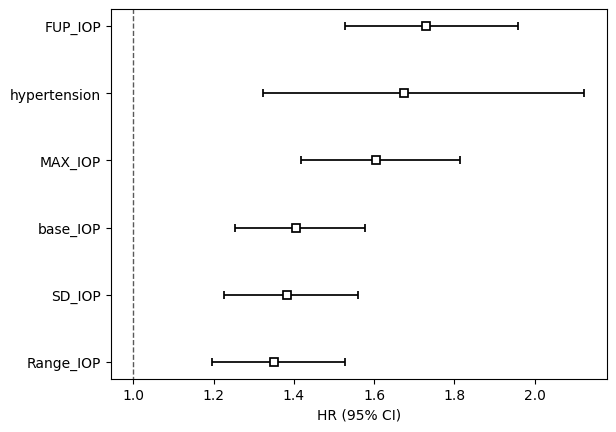

In [160]:
cph.plot(hazard_ratios=True)

### Schoenfeld's residuals and test


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 819 total observations, 540 right-censored observations>
         test_name = proportional_hazard_test

---
                   test_statistic    p  -log2(p)
FUP_IOP      km              0.40 0.53      0.92
             rank            0.23 0.63      0.67
MAX_IOP      km              0.11 0.74      0.43
             rank            0.11 0.75      0.42
Range_IOP    km              0.05 0.82      0.29
             rank            0.00 0.97      0.05
SD_IOP       km              0.00 0.95      0.07
             rank            0.00 0.98      0.03
base_IOP     km              0.03 0.86      0.23
             rank            0.13 0.72      0.47
hypertension km              4.70 0.03      5.05
             rank            4.84 0.03      5.17



1. Variable 'hypertension' failed the non-proportional test: p-value is 0.0278.

   Advice: with so few unique values (only 2), you can include `strata=['hypertension', ...]` in the
call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



[[<Axes: xlabel='rank-transformed time\n(p=0.7225)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8554)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6306)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5273)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7455)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7428)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9670)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8166)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9826)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9528)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0278)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0302)'>]]

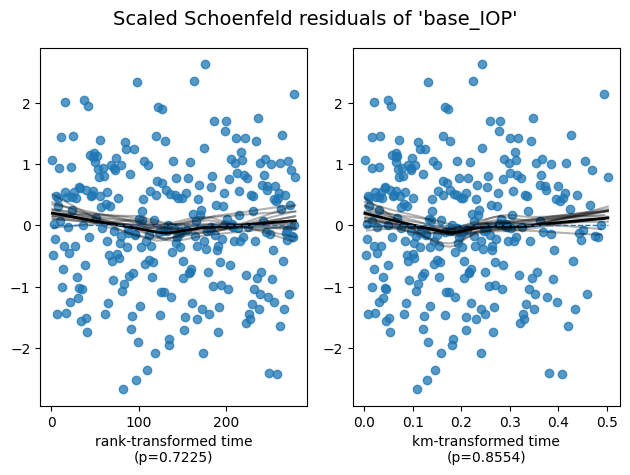

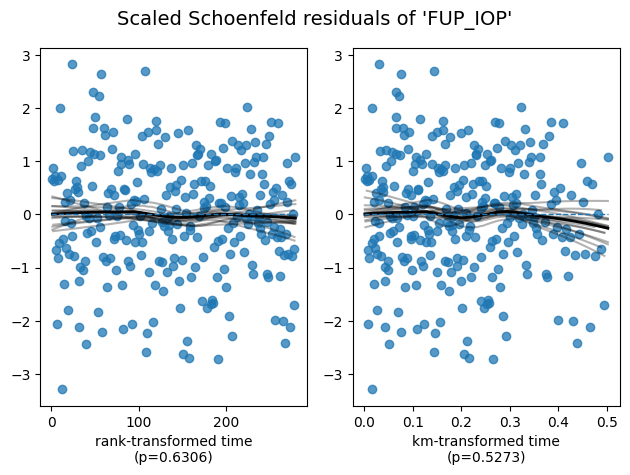

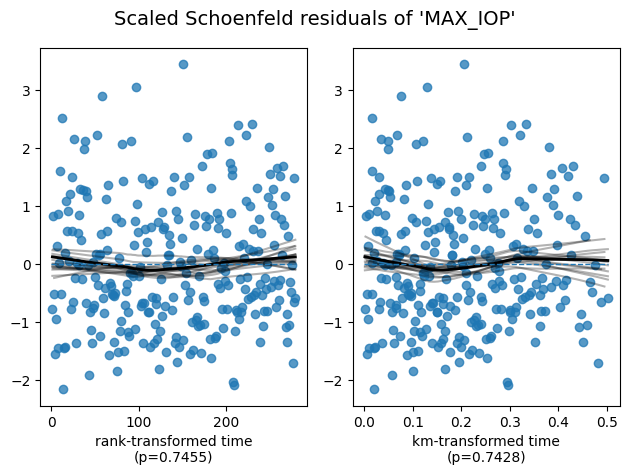

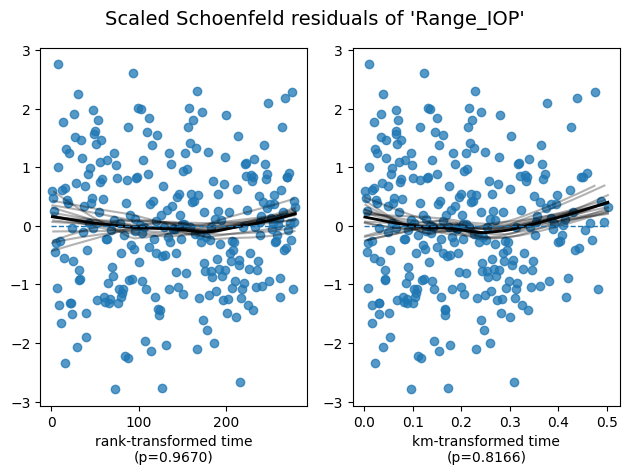

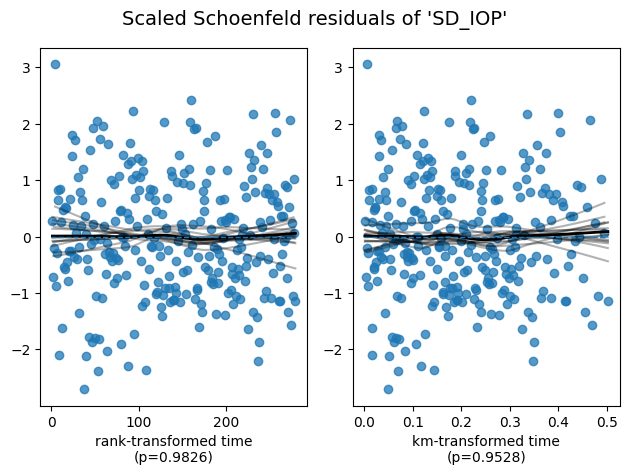

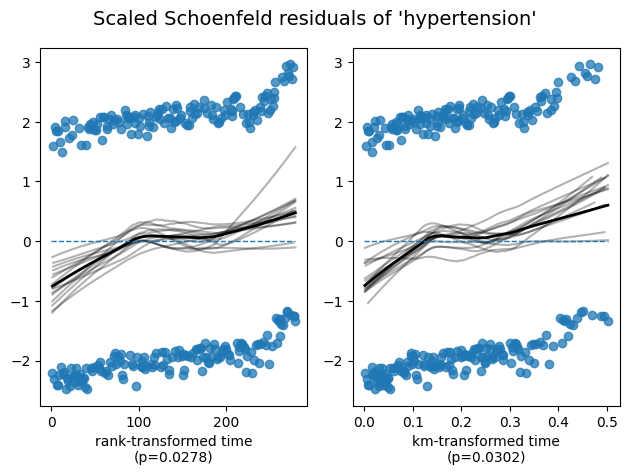

In [161]:
cph.check_assumptions(df_significant, p_value_threshold = 0.05, show_plots=True)

### Cross validation

In [162]:
features = df_significant.columns.to_list().copy()
scores = k_fold_cross_validation(cph, df_significant[features], 'time', event_col='status', k=10, scoring_method="concordance_index", seed=1234)
scores

print(np.mean(scores), np.std(scores))

0.745650235700577 0.044922761798364186


##*Stratifty w.r.t one variable*

### Fit the model

In [163]:
cph.fit(df_significant, duration_col = 'time', event_col = 'status', strata='hypertension')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 819 total observations, 540 right-censored observations>
             duration col = 'time'
                event col = 'status'
                   strata = hypertension
      baseline estimation = breslow
   number of observations = 819
number of events observed = 279
   partial log-likelihood = -1399.59
         time fit was run = 2024-12-17 20:27:53 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
base_IOP   0.35      1.41      0.06            0.23            0.46                1.26                1.58
FUP_IOP    0.56      1.75      0.06            0.43            0.68                1.54                1.98
MAX_IOP    0.47      1.60      0.06            0.35            0.59                1.41                1.81
Range_IOP  0.30      1.35      0.06            0.18            0.42                1.19                1.52
SD_IOP     0.33      1.40      0.06            0.21            0.46                1.24                1.58

           cmp to    z      p  -log2(p)
covariate                              
base_IOP     0.00 5.92 <0.005     28.19
FUP_IOP      0.00 8.71 <0.005     58.14
MAX_IOP      0.00 7.46 <0.005     43.35
Range_IOP    0.00 4.77 <0.005     19.05
SD_IOP       0.00 5.42 <0.005     24.04
---
Concordance = 0.75
Partial AIC = 2809.18
log-likelihood ratio test = 234.11 on 5 df
-log2(p) of ll-ratio test = 158.96

<Axes: xlabel='HR (95% CI)'>

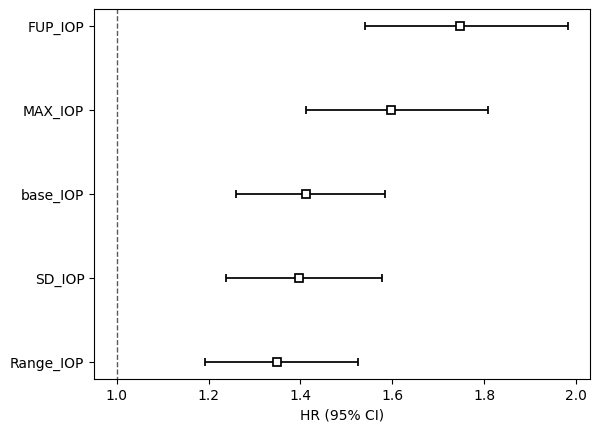

In [164]:
cph.plot(hazard_ratios=True)

### Schoenfeld's residuals and test


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.9938)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8415)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7756)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4526)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3685)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7277)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7253)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9067)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7762)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9561)'>]]

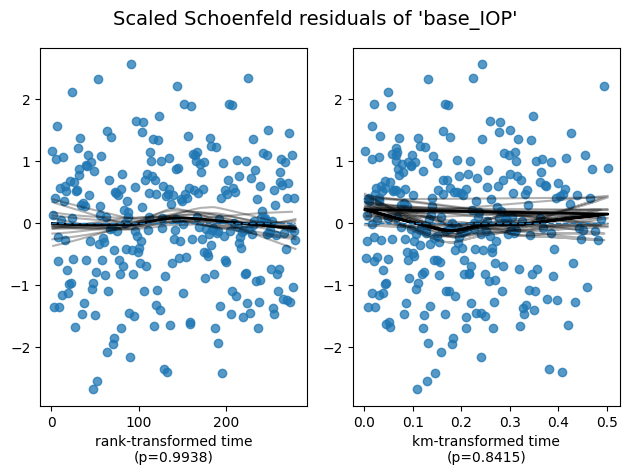

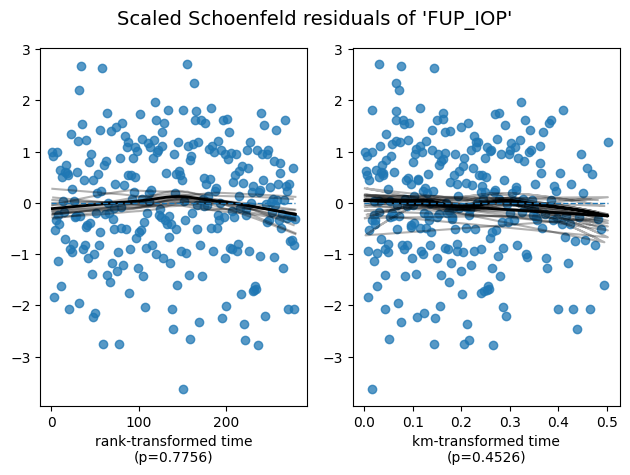

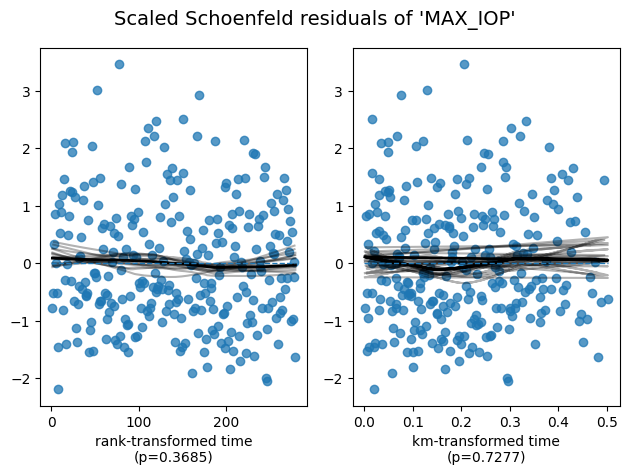

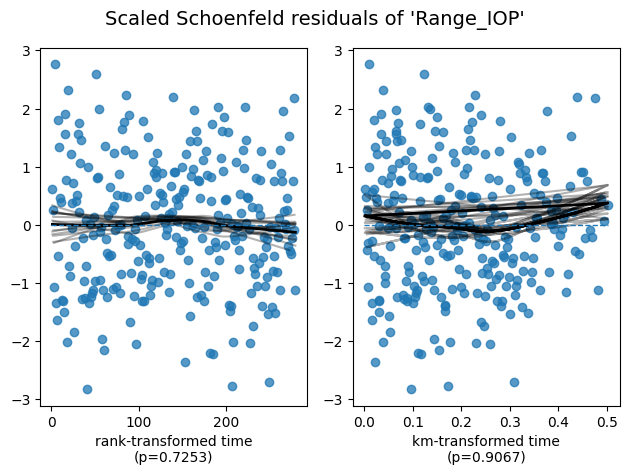

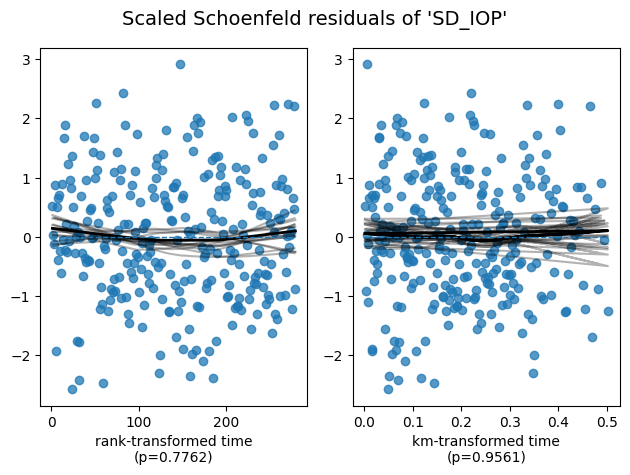

In [165]:
cph.check_assumptions(df_significant, p_value_threshold = 0.05, show_plots=True)

### Log-log KM

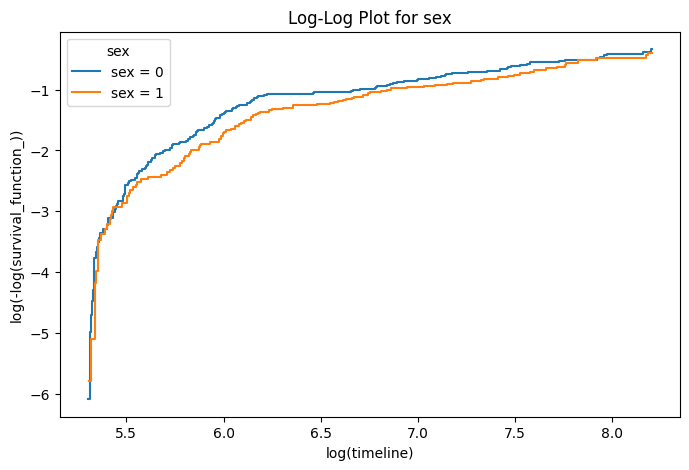

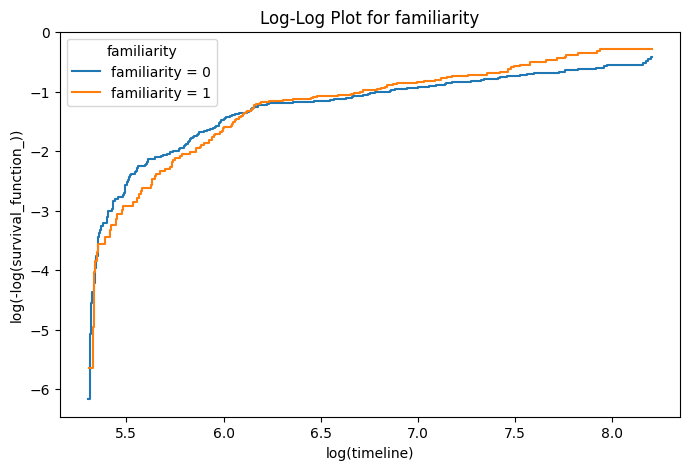

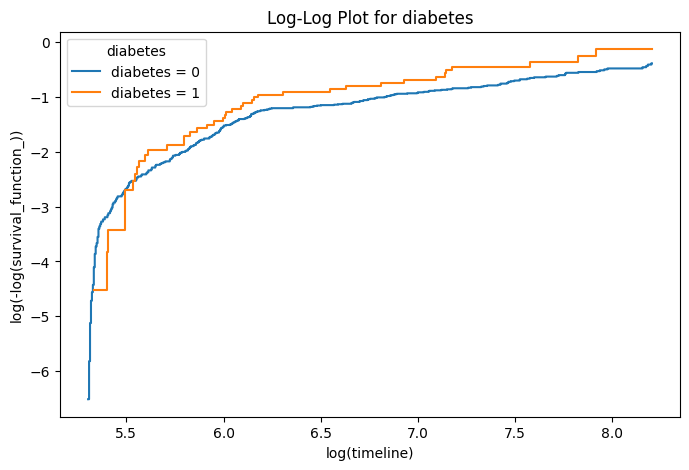

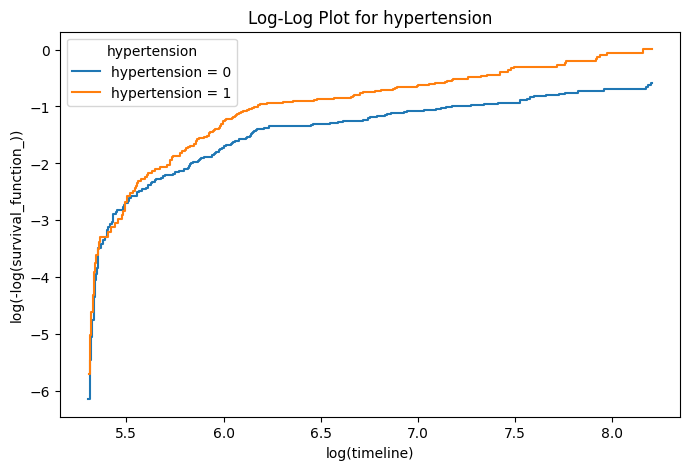

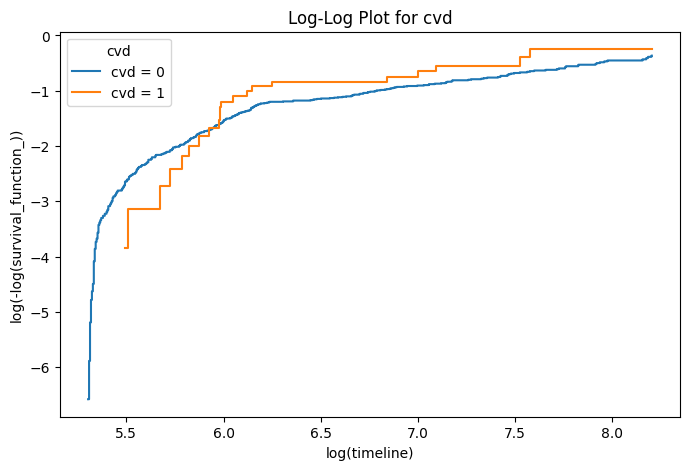

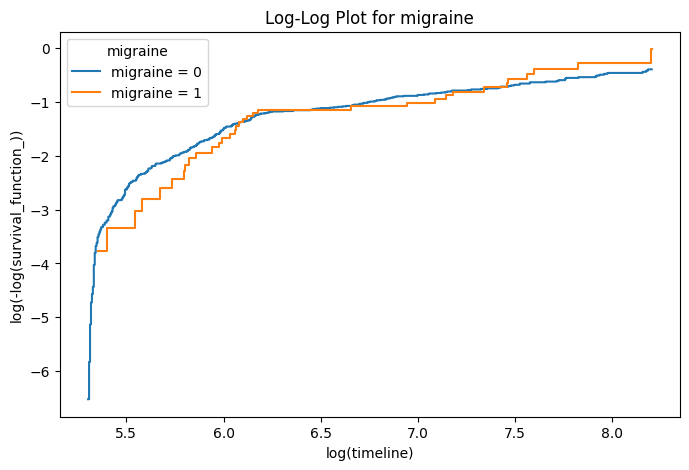

In [166]:
from lifelines.plotting import loglogs_plot

# List of categorical variables
categorical_vars = ['sex', 'familiarity', 'diabetes', 'hypertension', 'cvd', 'migraine']

# Survival time and event status
T = df['time']
E = df['status']

# Loop through each categorical variable
for var in categorical_vars:
    fig, ax = plt.subplots(figsize=(8, 5))  # Create a new figure for each variable

    # Define the groups (0 and 1)
    group_0 = (df[var] == 0)
    group_1 = (df[var] == 1)

    # Kaplan-Meier Fitter for group 0
    kmf = KaplanMeierFitter()
    kmf.fit(T[group_0], event_observed=E[group_0], label=f"{var} = 0")
    loglogs_plot(kmf, ax=ax)  # Log-log plot for group 0

    # Kaplan-Meier Fitter for group 1
    kmf.fit(T[group_1], event_observed=E[group_1], label=f"{var} = 1")
    loglogs_plot(kmf, ax=ax)  # Log-log plot for group 1

    # Add title and legend
    plt.title(f"Log-Log Plot for {var}")
    plt.legend(title=var)
    plt.show()


<Axes: xlabel='log(timeline)', ylabel='log(-log(survival_function_))'>

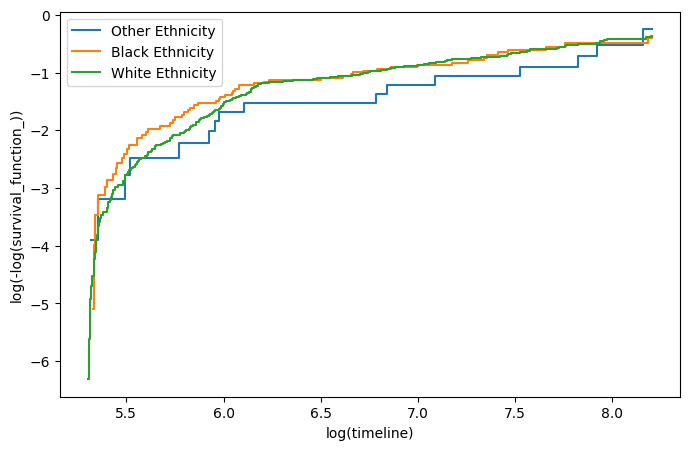

In [167]:
from lifelines.plotting import loglogs_plot

kmf = KaplanMeierFitter()

ethnicity_others = df['ethnicity'] == "Other"
ethnicity_black = df['ethnicity'] == "Black"
ethnicity_white = df['ethnicity'] == "White"

fig, ax = plt.subplots(figsize=(8,5))

kmf.fit(df.loc[ethnicity_others]['time'], event_observed=df.loc[ethnicity_others]['status'], label="Other Ethnicity")
loglogs_plot(kmf, ax=ax)

kmf.fit(df.loc[ethnicity_black]['time'], event_observed=df.loc[ethnicity_black]['status'], label="Black Ethnicity")
loglogs_plot(kmf, ax=ax)

kmf.fit(df.loc[ethnicity_white]['time'], event_observed=df.loc[ethnicity_white]['status'], label="White Ethnicity")
loglogs_plot(kmf, ax=ax)

### Martingale and deviance residuals

In [168]:
mr = cph.compute_residuals(df_significant, 'martingale')
mr.head()

/usr/local/lib/python3.10/dist-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


,time,status,martingale
291,56.37,False,0.00
52,60.98,False,0.00
780,75.01,False,0.00
698,77.27,False,0.00
14,78.69,False,0.00


In [169]:
from statsmodels.nonparametric.smoothers_lowess import lowess as lowess

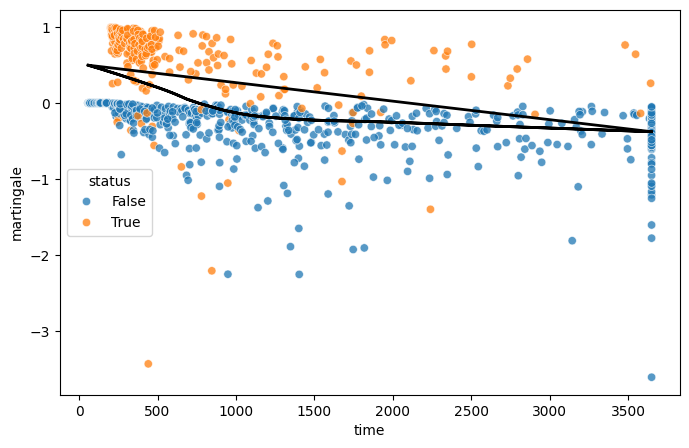

In [170]:
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=mr,
    x='time', y='martingale', hue='status',
    alpha=0.75,
    ax=ax
)
y_lowess = lowess(mr.martingale.values, mr.time.values, return_sorted=False)
ax.plot(mr.time.values, y_lowess, color="k", alpha=1.0, linewidth=2)
plt.show()

In [171]:
dr = cph.compute_residuals(df_significant, 'deviance')
dr.head()

/usr/local/lib/python3.10/dist-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


,time,status,deviance
291,56.37,False,-0.00
52,60.98,False,-0.00
780,75.01,False,-0.00
698,77.27,False,-0.00
14,78.69,False,-0.00


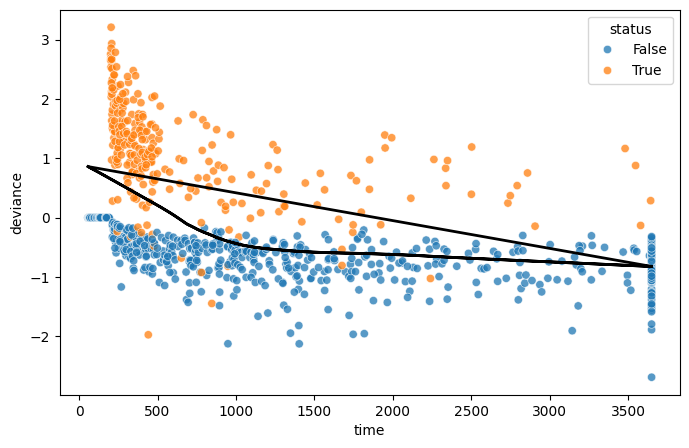

In [172]:
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=dr,
    x='time', y='deviance', hue='status',
    alpha=0.75,
    ax=ax
)
y_lowess = lowess(dr.deviance.values, dr.time.values, return_sorted=False)
ax.plot(dr.time.values, y_lowess, color="k", alpha=1.0, linewidth=2, zorder=2)
plt.show()

### Cross Validation

In [173]:
from lifelines.utils import k_fold_cross_validation
features = df_significant.columns.to_list().copy()
scores = k_fold_cross_validation(cph, df_significant[features], 'time', event_col='status', k=10, scoring_method="concordance_index", seed=1234)
scores

/usr/local/lib/python3.10/dist-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/usr/local/lib/python3.10/dist-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/usr/local/lib/python3.10/dist-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/usr/local/lib/python3.10/dist-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead

[0.8137044967880086,
 0.7801857585139319,
 0.6881720430107527,
 0.7230014025245441,
 0.759656652360515,
 0.6387240356083086,
 0.7955840455840456,
 0.7018132975151108,
 0.7676579925650557,
 0.7012893982808023]

In [174]:
print(np.mean(scores), np.std(scores))

0.7369789122751075 0.052331212788688096


# **Impact of IOP Variability on Progression Risk Across Patient Subgroups**

In [175]:
# Divide SD_IOP and Range_IOP into High and Low groups using the median
df_enc['SD_IOP_group'] = np.where(df_enc['SD_IOP'] >= df_enc['SD_IOP'].median(), 'High', 'Low')
df_enc['Range_IOP_group'] = np.where(df_enc['Range_IOP'] >= df_enc['Range_IOP'].median(), 'High', 'Low')

# Categorical variables to consider
categorical_vars = ['sex', 'familiarity', 'diabetes', 'hypertension', 'cvd', 'migraine']

for cat_var in categorical_vars:
    # Create combinations of SD_IOP and the categorical variable
    group1 = df_enc[(df_enc['SD_IOP_group'] == 'High') & (df_enc[cat_var] == 1)]
    group2 = df_enc[(df_enc['SD_IOP_group'] == 'Low') & (df_enc[cat_var] == 1)]
    group3 = df_enc[(df_enc['SD_IOP_group'] == 'High') & (df_enc[cat_var] == 0)]
    group4 = df_enc[(df_enc['SD_IOP_group'] == 'Low') & (df_enc[cat_var] == 0)]

    #Log-Rank test between all groups
    result1 = logrank_test(group1['time'], group2['time'], event_observed_A=group1['status'], event_observed_B=group2['status'])
    print(f"Log-Rank Test between High and Low SD_IOP within {cat_var}=1: p-value = {result1.p_value:.4f}")

    result2 = logrank_test(group3['time'], group4['time'], event_observed_A=group3['status'], event_observed_B=group4['status'])
    print(f"Log-Rank Test between High and Low SD_IOP within {cat_var}=0: p-value = {result2.p_value:.4f}")

Log-Rank Test between High and Low SD_IOP within sex=1: p-value = 0.0581
Log-Rank Test between High and Low SD_IOP within sex=0: p-value = 0.0205
Log-Rank Test between High and Low SD_IOP within familiarity=1: p-value = 0.2652
Log-Rank Test between High and Low SD_IOP within familiarity=0: p-value = 0.0043
Log-Rank Test between High and Low SD_IOP within diabetes=1: p-value = 0.0059
Log-Rank Test between High and Low SD_IOP within diabetes=0: p-value = 0.0360
Log-Rank Test between High and Low SD_IOP within hypertension=1: p-value = 0.0917
Log-Rank Test between High and Low SD_IOP within hypertension=0: p-value = 0.0065
Log-Rank Test between High and Low SD_IOP within cvd=1: p-value = 0.4115
Log-Rank Test between High and Low SD_IOP within cvd=0: p-value = 0.0008
Log-Rank Test between High and Low SD_IOP within migraine=1: p-value = 0.5053
Log-Rank Test between High and Low SD_IOP within migraine=0: p-value = 0.0040


In [176]:
# Divide Range_IOP into High and Low groups using the median
df_enc['Range_IOP_group'] = np.where(df_enc['Range_IOP'] >= df_enc['Range_IOP'].median(), 'High', 'Low')

# Categorical variables to consider
categorical_vars = ['sex', 'familiarity', 'diabetes', 'hypertension', 'cvd', 'migraine']

for cat_var in categorical_vars:
    # Create combinations of Range_IOP and the categorical variable
    group1 = df_enc[(df_enc['Range_IOP_group'] == 'High') & (df_enc[cat_var] == 1)]
    group2 = df_enc[(df_enc['Range_IOP_group'] == 'Low') & (df_enc[cat_var] == 1)]
    group3 = df_enc[(df_enc['Range_IOP_group'] == 'High') & (df_enc[cat_var] == 0)]
    group4 = df_enc[(df_enc['Range_IOP_group'] == 'Low') & (df_enc[cat_var] == 0)]

    #Log-Rank test between all groups
    result1 = logrank_test(group1['time'], group2['time'], event_observed_A=group1['status'], event_observed_B=group2['status'])
    print(f"Log-Rank Test between High and Low Range_IOP within {cat_var}=1: p-value = {result1.p_value:.4f}")

    result2 = logrank_test(group3['time'], group4['time'], event_observed_A=group3['status'], event_observed_B=group4['status'])
    print(f"Log-Rank Test between High and Low Range_IOP within {cat_var}=0: p-value = {result2.p_value:.4f}")

Log-Rank Test between High and Low Range_IOP within sex=1: p-value = 0.0095
Log-Rank Test between High and Low Range_IOP within sex=0: p-value = 0.0600
Log-Rank Test between High and Low Range_IOP within familiarity=1: p-value = 0.2487
Log-Rank Test between High and Low Range_IOP within familiarity=0: p-value = 0.0017
Log-Rank Test between High and Low Range_IOP within diabetes=1: p-value = 0.0202
Log-Rank Test between High and Low Range_IOP within diabetes=0: p-value = 0.0145
Log-Rank Test between High and Low Range_IOP within hypertension=1: p-value = 0.0085
Log-Rank Test between High and Low Range_IOP within hypertension=0: p-value = 0.0680
Log-Rank Test between High and Low Range_IOP within cvd=1: p-value = 0.5603
Log-Rank Test between High and Low Range_IOP within cvd=0: p-value = 0.0010
Log-Rank Test between High and Low Range_IOP within migraine=1: p-value = 0.1598
Log-Rank Test between High and Low Range_IOP within migraine=0: p-value = 0.0053
